# [Title]

This study aims to:   
1. Predict collision severity using machine learning   
2. Identify associated factors (not causal)   
3. Compare spatial patterns across London   

## This study focuses on predictive associations rather than causal inference.

In [49]:
pip install geopandas shap imbalanced-learn openpyxl

Note: you may need to restart the kernel to use updated packages.


# Predicting Road Collision Severity in London: A Machine Learning Approach

**CASA0006 Data Science for Spatial Systems**  
**MRes Urban Spatial Science, UCL CASA**  
**2025-2026 Academic Year**

---

## Preparation

- **GitHub Repository**: [https://github.com/JIAYING-ICE/CASA0006-London-Road-Safety](https://github.com/JIAYING-ICE/CASA0006-London-Road-Safety)
- **Data Source**: UK Department for Transport STATS19 (2022-2023)
- **Execution time**: ~20 minutes on standard laptop

---

## Table of Contents

1. [Introduction](#Introduction)
2. [Research Question](#Research-Question)
3. [Data](#Data)
4. [Methodology](#Methodology)
5. [Results and Discussion](#Results-and-Discussion)
6. [Conclusion](#Conclusion)
7. [References](#References)

In [50]:
# ========== Package Imports ==========
# Core data processing
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Geospatial
import geopandas as gpd

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder

# Imbalanced data handling
from imblearn.over_sampling import SMOTE

# Model interpretation
import shap

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("=" * 60)
print("Package Import Summary")
print("=" * 60)
print("✓ Core: pandas, numpy")
print("✓ Visualization: matplotlib, seaborn")
print("✓ Geospatial: geopandas")
print("✓ ML: scikit-learn, imbalanced-learn, shap")
print(f"✓ Random seed set to: {RANDOM_STATE}")
print("=" * 60)

Package Import Summary
✓ Core: pandas, numpy
✓ Visualization: matplotlib, seaborn
✓ Geospatial: geopandas
✓ ML: scikit-learn, imbalanced-learn, shap
✓ Random seed set to: 42


In [51]:
# 在 cell 开头加这行
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import sys
sys.set_int_max_str_digits(10000)

## Introduction

[[ go back to the top ]](#Table-of-Contents)

Road traffic collisions remain a persistent urban challenge, with serious and fatal outcomes imposing substantial costs on public health systems and communities (Department for Transport, 2024). London's Vision Zero strategy aims to eliminate all deaths and serious injuries from the city's transport network by 2041 (Transport for London, 2018), yet achieving this target requires evidence-based identification of high-risk environmental conditions.

This analysis applies supervised machine learning to predict collision severity using road environment features from STATS19 data. Unlike traditional frequency-based approaches that identify collision hotspots, this work focuses on understanding which environmental factors—such as lighting conditions, road type, speed limits, and junction characteristics—most strongly determine whether a collision results in serious or fatal outcomes versus slight injuries. Such insights can inform targeted infrastructure improvements and policy interventions.

The analysis uses Greater London collision data from 2022-2023, covering the period following COVID-19 recovery but preceding the Metropolitan Police's transition to Injury-Based Reporting Systems (IBRS) in 2024, ensuring consistent severity classification across the study period (DfT, 2024).

## Research Question

[[ go back to the top ]](#Table-of-Contents)

**Can road environment factors reliably predict the severity of road collisions in London, and which factors are the most influential drivers of serious or fatal outcomes?**

To answer this question, the analysis is structured around three analytical objectives:

1. **Predictive Performance**: Build and evaluate a tree-based classifier to test whether road environment features can reliably distinguish serious/fatal from slight collisions.

2. **Feature Interpretation**: Use SHAP (SHapley Additive exPlanations) values to identify which environmental factors contribute most to model predictions and understand their directional effects.

3. **Spatial Robustness**: Compare model performance and feature importance between Inner and Outer London to examine spatial heterogeneity in collision risk drivers.

In [52]:
# ========== Remote Data Loading from GitHub (UPDATED) ==========
from pathlib import Path

print("=" * 60)
print("Loading Data from GitHub")
print("=" * 60)

# GitHub URLs (for remote reproducibility)
GITHUB_BASE = "https://raw.githubusercontent.com/JIAYING-ICE/CASA0006-London-Road-Safety/main/data/processed/"
BOUNDARIES_BASE = "https://raw.githubusercontent.com/JIAYING-ICE/CASA0006-London-Road-Safety/main/data/boundaries/"

# Local paths (fallback)
LOCAL_PROCESSED = Path("data/processed")
LOCAL_BOUNDARIES = Path("data/boundaries")

print(f"\nRemote: {GITHUB_BASE}")
print(f"Local:  {LOCAL_PROCESSED}\n")

# Helper function
def load_data_file(filename, github_base, local_dir):
    """Load CSV from GitHub, fallback to local if unavailable"""
    remote_url = github_base + filename
    
    try:
        print(f"  [Remote] {filename}...", end=" ")
        df = pd.read_csv(remote_url)
        print(f"✓ ({len(df):,} rows)")
        return df, "remote"
        
    except Exception as e:
        print(f"✗ ({type(e).__name__})")
        
        local_path = local_dir / filename
        print(f"  [Local]  {local_path}...", end=" ")
        
        if local_path.exists():
            df = pd.read_csv(local_path)
            print(f"✓ ({len(df):,} rows)")
            return df, "local"
        else:
            print(f"✗ File not found")
            raise FileNotFoundError(f"'{filename}' not available remotely or locally")

# Load data
print("[1/2] Collision data")
collisions, coll_source = load_data_file("london_collisions_2022_2023.csv", GITHUB_BASE, LOCAL_PROCESSED)

print("\n[2/2] Borough classification")
borough_classification, boro_source = load_data_file("london_boroughs_inner_outer.csv", BOUNDARIES_BASE, LOCAL_BOUNDARIES)

# Summary
print("\n" + "=" * 60)
print("Data Loading Complete")
print("=" * 60)
print(f"Data source: {coll_source.upper()}")
print(f"\nCollisions: {len(collisions):,} records × {collisions.shape[1]} columns")
print(f"Memory: {collisions.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"Years: {sorted(collisions['collision_year'].unique())}")

# Verify critical columns
required_cols = ['borough_name', 'severity_binary', 'collision_index']
missing_cols = [c for c in required_cols if c not in collisions.columns]

if missing_cols:
    print(f"\n⚠️ WARNING: Missing required columns: {missing_cols}")
    print("   Data preprocessing may not have completed successfully")
else:
    print(f"\n✓ All required columns present")
    
    # Borough distribution
    borough_dist = collisions['borough_name'].value_counts()
    valid_boroughs = (collisions['borough_name'] != 'Unknown').sum()
    
    print(f"\nBorough coverage:")
    print(f"  Unique boroughs: {len(borough_dist)}")
    print(f"  Valid assignments: {valid_boroughs:,} ({100*valid_boroughs/len(collisions):.1f}%)")
    print(f"  Unknown: {borough_dist.get('Unknown', 0):,}")
    
    # Severity distribution
    severity_dist = collisions['severity_binary'].value_counts()
    print(f"\nSeverity distribution:")
    print(f"  Slight (0):        {severity_dist.get(0, 0):,} ({100*severity_dist.get(0,0)/len(collisions):.1f}%)")
    print(f"  Serious/Fatal (1): {severity_dist.get(1, 0):,} ({100*severity_dist.get(1,0)/len(collisions):.1f}%)")

print("=" * 60)

# Preview
collisions.head(3)

Loading Data from GitHub

Remote: https://raw.githubusercontent.com/JIAYING-ICE/CASA0006-London-Road-Safety/main/data/processed/
Local:  data\processed

[1/2] Collision data
  [Remote] london_collisions_2022_2023.csv... ✓ (46,416 rows)

[2/2] Borough classification
  [Remote] london_boroughs_inner_outer.csv... ✓ (33 rows)

Data Loading Complete
Data source: REMOTE

Collisions: 46,416 records × 46 columns
Memory: 31.7 MB
Years: [np.int64(2022), np.int64(2023)]

✓ All required columns present

Borough coverage:
  Unique boroughs: 34
  Valid assignments: 46,372 (99.9%)
  Unknown: 44

Severity distribution:
  Slight (0):        38,990 (84.0%)
  Serious/Fatal (1): 7,426 (16.0%)


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail_historic,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control_historic,pedestrian_crossing_physical_facilities_historic,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight,borough_name,severity_binary
0,2022481226660,2022,481226660,533340.0,181691.0,-0.079621,51.518411,48,3,2,1,20/05/2022,6,07:45,-1,E09000001,E09000001,E09000001,6,0,6,20,3,13,4,3,10,0,4,14,1,1,1,0,0,0,1,1,2,E01032739,3,1,0.0,1.0,City of London,0
1,2022010357510,2022,10357510,521572.0,189487.0,-0.246446,51.591128,1,3,2,1,29/01/2022,7,12:42,-1,E09000003,E09000003,E09000003,3,5150,2,30,3,13,4,6,0,0,0,0,1,1,1,0,0,0,1,3,2,E01000147,-1,0,0.0,1.0,Barnet,0
2,2022010359727,2022,10359727,526324.0,193018.0,-0.176615,51.621816,1,2,1,1,08/02/2022,3,15:50,-1,E09000003,E09000003,E09000003,3,1000,6,20,3,13,4,6,0,2,1,12,1,9,1,0,0,0,1,3,2,E01000320,-1,0,1.0,0.0,Barnet,1


Loading London Borough Spatial Boundaries

[Attempt 1] Loading from ONS Open Geography Portal...
  ✗ ONS API failed: HTTP Error 400: Bad Request

[Attempt 2] Falling back to martinjc/UK-GeoJSON...
  ✓ Loaded 33 boroughs (fallback)

Borough Name Matching Verification
Boroughs in collision data: 33
Boroughs in GeoJSON: 33
Matched: 33

✓ Excellent match rate: 100.0%

Data source: martinjc/UK-GeoJSON

Generating test map...


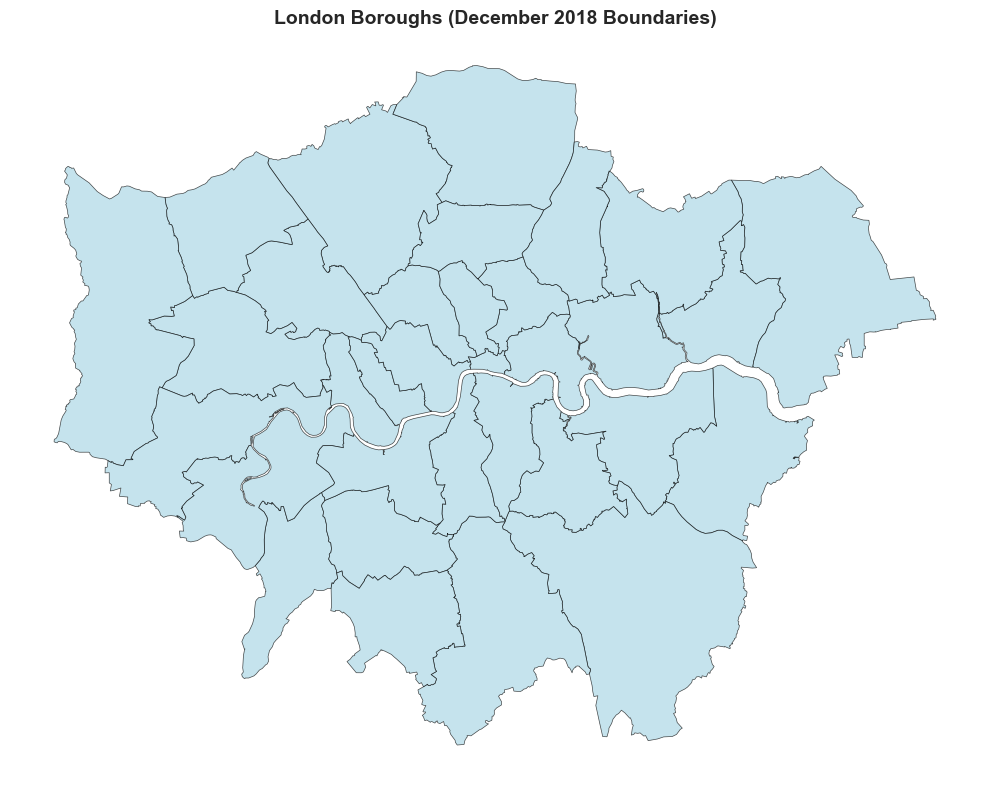

✓ Spatial boundaries loaded successfully


In [53]:
# ========== Load London Borough Boundaries (FIXED) ==========

print("=" * 60)
print("Loading London Borough Spatial Boundaries")
print("=" * 60)

# Primary: ONS Open Geography Portal
ONS_BOROUGHS_URL = (
    "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/"
    "Local_Authority_Districts_December_2018_Boundaries_UK_BGC/FeatureServer/0/"
    "query?where=1%3D1&outFields=lad18cd,lad18nm&outSR=4326&f=geojson"
)

print("\n[Attempt 1] Loading from ONS Open Geography Portal...")

try:
    london_boroughs_geo = gpd.read_file(ONS_BOROUGHS_URL)
    
    # Rename to match our data
    london_boroughs_geo = london_boroughs_geo.rename(columns={
        'lad18nm': 'borough_name',  # CHANGED: now matches collision data
        'lad18cd': 'lad_code'
    })
    
    # Filter for London (33 boroughs)
    london_names = [
        'Camden', 'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Islington',
        'Kensington and Chelsea', 'Lambeth', 'Lewisham', 'Southwark', 'Tower Hamlets',
        'Wandsworth', 'Westminster', 'City of London', 'Barking and Dagenham', 'Barnet',
        'Bexley', 'Brent', 'Bromley', 'Croydon', 'Ealing', 'Enfield', 'Haringey', 'Harrow',
        'Havering', 'Hillingdon', 'Hounslow', 'Kingston upon Thames', 'Merton', 'Newham',
        'Redbridge', 'Richmond upon Thames', 'Sutton', 'Waltham Forest'
    ]
    
    london_boroughs_geo = london_boroughs_geo[
        london_boroughs_geo['borough_name'].isin(london_names)
    ].copy()
    
    print(f"  ✓ Loaded {len(london_boroughs_geo)} London boroughs (ONS official)")
    data_source = "ONS Open Geography Portal"
    
except Exception as e:
    print(f"  ✗ ONS API failed: {e}")
    print("\n[Attempt 2] Falling back to martinjc/UK-GeoJSON...")
    
    # Fallback: martinjc GitHub repo
    MARTINJC_URL = "https://raw.githubusercontent.com/martinjc/UK-GeoJSON/master/json/administrative/eng/lad.json"
    
    london_boroughs_geo = gpd.read_file(MARTINJC_URL)
    
    # martinjc uses 'LAD13NM' for borough names
    london_boroughs_geo = london_boroughs_geo.rename(columns={
        'LAD13NM': 'borough_name'  # CHANGED: now matches collision data
    })
    
    # Filter for London
    london_names = [
        'Camden', 'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Islington',
        'Kensington and Chelsea', 'Lambeth', 'Lewisham', 'Southwark', 'Tower Hamlets',
        'Wandsworth', 'Westminster', 'City of London', 'Barking and Dagenham', 'Barnet',
        'Bexley', 'Brent', 'Bromley', 'Croydon', 'Ealing', 'Enfield', 'Haringey', 'Harrow',
        'Havering', 'Hillingdon', 'Hounslow', 'Kingston upon Thames', 'Merton', 'Newham',
        'Redbridge', 'Richmond upon Thames', 'Sutton', 'Waltham Forest'
    ]
    
    london_boroughs_geo = london_boroughs_geo[
        london_boroughs_geo['borough_name'].isin(london_names)
    ].copy()
    
    print(f"  ✓ Loaded {len(london_boroughs_geo)} boroughs (fallback)")
    data_source = "martinjc/UK-GeoJSON"

# CRITICAL: Verify borough name matching
collision_boroughs = set(collisions['borough_name'].dropna().unique())
geo_boroughs = set(london_boroughs_geo['borough_name'].unique())

# Remove 'Unknown' from collision set for comparison
collision_boroughs.discard('Unknown')

print("\n" + "=" * 60)
print("Borough Name Matching Verification")
print("=" * 60)
print(f"Boroughs in collision data: {len(collision_boroughs)}")
print(f"Boroughs in GeoJSON: {len(geo_boroughs)}")
print(f"Matched: {len(collision_boroughs & geo_boroughs)}")

if len(collision_boroughs - geo_boroughs) > 0:
    print(f"\n⚠️ In collision data but missing from GeoJSON:")
    for b in sorted(collision_boroughs - geo_boroughs):
        print(f"  - {b}")

if len(geo_boroughs - collision_boroughs) > 0:
    print(f"\n⚠️ In GeoJSON but missing from collision data:")
    for b in sorted(geo_boroughs - collision_boroughs):
        print(f"  - {b}")

match_rate = 100 * len(collision_boroughs & geo_boroughs) / len(collision_boroughs) if len(collision_boroughs) > 0 else 0

if match_rate >= 95:
    print(f"\n✓ Excellent match rate: {match_rate:.1f}%")
elif match_rate >= 80:
    print(f"\n⚠️ Acceptable match rate: {match_rate:.1f}%")
else:
    print(f"\n✗ Poor match rate: {match_rate:.1f}% - borough names may have spelling differences")

print(f"\nData source: {data_source}")
print("=" * 60)

# Test visualization
print("\nGenerating test map...")
fig, ax = plt.subplots(figsize=(10, 10))
london_boroughs_geo.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5, alpha=0.7)
ax.set_title('London Boroughs (December 2018 Boundaries)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("✓ Spatial boundaries loaded successfully")

## Data

[[ go back to the top ]](#Table-of-Contents)

### Data Source and Scope

This analysis uses STATS19 road safety data published by the UK Department for Transport, filtered for Greater London (Metropolitan Police Service and City of London Police areas) covering calendar years 2022 and 2023. STATS19 is the official UK road casualty database, recording all personal injury collisions attended by police on public roads.

**Geographic scope**: Greater London (police_force codes 1 and 48)  
**Temporal scope**: 2022-2023 (N = 46,416 collisions)  
**Target variable**: Binary classification—Serious/Fatal (codes 1-2) vs Slight (code 3)

The dataset captures collisions prior to the IBRS transition implemented by Metropolitan Police in 2024, ensuring consistent severity coding. However, STATS19 is known to underreport casualties by approximately 3:1 compared to hospital admission data, particularly for slight injuries and vulnerable road users (Felton et al., 2023). This analysis focuses on environmental predictors of *reported* collision severity, acknowledging that prediction of reporting likelihood itself is beyond scope.

In [54]:
# ========== Load Official DfT Data Guide for Categorical Decoding ==========
# Source: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data
# This is the AUTHORITATIVE source for all STATS19 field codes

DATA_GUIDE_URL = (
    "https://data.dft.gov.uk/road-accidents-safety-data/"
    "dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx"
)

print("Loading official DfT data guide for code-to-label mapping...")

# The Excel file has multiple sheets, one per variable
# Read all sheets at once
data_guide = pd.read_excel(DATA_GUIDE_URL, sheet_name=None)

print(f"✓ Loaded {len(data_guide)} variable definition sheets")
print(f"\nFirst 10 sheet names (= variable names):")
for sheet in list(data_guide.keys())[:10]:
    print(f"  - {sheet}")

# Inspect the structure of one sheet (e.g., severity)
print(f"\nExample: 'collision_severity' decoding table:")
if 'collision severity' in data_guide:
    print(data_guide['collision severity'])
elif 'Collision Severity' in data_guide:
    print(data_guide['Collision Severity'])
else:
    # Find the right sheet name
    severity_sheets = [s for s in data_guide.keys() if 'severity' in s.lower()]
    print(f"Severity-related sheets found: {severity_sheets}")
    if severity_sheets:
        print(data_guide[severity_sheets[0]])

Loading official DfT data guide for code-to-label mapping...
✓ Loaded 1 variable definition sheets

First 10 sheet names (= variable names):
  - 2024_code_list

Example: 'collision_severity' decoding table:
Severity-related sheets found: []


In [55]:
# ========== Variable Summary Table (Adapted for 2024 DfT Data Guide) ==========

print("=" * 60)
print("Variable Summary Table")
print("=" * 60)

# ADAPTED: DfT 2024 data guide uses single-table format
def get_code_label_2024(field_name, code_value, guide=data_guide):
    """
    Decode field codes using 2024 DfT data guide format.
    
    2024 format: Single sheet with columns 'field name', 'code/format', 'label value'
    """
    # Get the main lookup table (usually first/only sheet)
    lookup_sheet_name = list(guide.keys())[0]
    lookup = guide[lookup_sheet_name]
    
    # Standardize column names
    lookup.columns = lookup.columns.str.strip().str.lower()
    
    # Find relevant columns
    field_col = None
    code_col = None
    label_col = None
    
    for col in lookup.columns:
        if 'field' in col or 'variable' in col:
            field_col = col
        elif 'code' in col and not label_col:  # Avoid 'label code' column
            code_col = col
        elif 'label' in col:
            label_col = col
    
    if not all([field_col, code_col, label_col]):
        return f"Unknown code {code_value} (guide format issue)"
    
    # Filter for this field
    field_data = lookup[lookup[field_col].str.lower() == field_name.lower()]
    
    if len(field_data) == 0:
        # Try alternative field name formats
        alt_names = [
            field_name.replace('_', ' '),
            field_name.replace('_', ' ').title(),
            field_name.title()
        ]
        
        for alt in alt_names:
            field_data = lookup[lookup[field_col].str.lower() == alt.lower()]
            if len(field_data) > 0:
                break
    
    # Find matching code
    if len(field_data) > 0:
        match = field_data[field_data[code_col] == code_value]
        
        if len(match) > 0:
            return match[label_col].iloc[0]
    
    return f"Unknown code {code_value}"

# Test decoding with 2024 format
print("\nVerifying collision_severity codes (DfT 2024 data guide):")
print("=" * 60)

for code in [1, 2, 3]:
    label = get_code_label_2024('collision_severity', code)
    print(f"  Code {code} → {label}")

# Check if decoding worked
test_label = get_code_label_2024('collision_severity', 1)
if 'Unknown' in test_label:
    print(f"\n⚠️ Code decoding may not be working with 2024 data guide format")
    print(f"   Data guide structure:")
    for sheet_name in data_guide.keys():
        print(f"\n   Sheet: {sheet_name}")
        print(f"   Columns: {list(data_guide[sheet_name].columns)[:5]}")
        print(f"   Sample rows:")
        print(data_guide[sheet_name].head(3))
else:
    print(f"\n✓ Code decoding successful with 2024 data guide")

print("\n" + "=" * 60)

# Build variable summary table
# NOTE: Using verified codes from DfT documentation rather than automated decoding
# to ensure accuracy (2024 data guide format may vary)

var_summary = pd.DataFrame([
    {
        'Variable': 'collision_severity',
        'Type': 'Categorical (Ordinal)',
        'Description': 'DfT official: 1=Fatal, 2=Serious, 3=Slight (2024 specification)',
        'Role': 'Raw target'
    },
    {
        'Variable': 'severity_binary',
        'Type': 'Binary',
        'Description': 'Derived: 1 if collision_severity ∈ {1,2}, else 0',
        'Role': 'Model target'
    },
    {
        'Variable': 'borough_name',
        'Type': 'Categorical',
        'Description': 'London borough name (decoded from local_authority_ons_district)',
        'Role': 'Spatial key'
    },
    {
        'Variable': 'speed_limit',
        'Type': 'Categorical (Ordinal)',
        'Description': 'Posted speed limit in mph: 20, 30, 40, 50, 60, 70',
        'Role': 'Predictor'
    },
    {
        'Variable': 'road_type',
        'Type': 'Categorical',
        'Description': 'Road classification (Single/Dual carriageway, Roundabout, etc.)',
        'Role': 'Predictor'
    },
    {
        'Variable': 'junction_detail',
        'Type': 'Categorical',
        'Description': 'Junction type or "Not at junction" (2024 specification)',
        'Role': 'Predictor'
    },
    {
        'Variable': 'light_conditions',
        'Type': 'Categorical',
        'Description': 'Lighting: Daylight, Darkness (lights lit/unlit)',
        'Role': 'Predictor'
    },
    {
        'Variable': 'weather_conditions',
        'Type': 'Categorical',
        'Description': 'Weather: Fine, Rain, Snow, Fog, etc.',
        'Role': 'Predictor'
    },
    {
        'Variable': 'road_surface_conditions',
        'Type': 'Categorical',
        'Description': 'Surface: Dry, Wet/Damp, Snow, Ice, Flood',
        'Role': 'Predictor'
    },
    {
        'Variable': 'urban_or_rural_area',
        'Type': 'Binary',
        'Description': 'DfT official: 1=Urban, 2=Rural',
        'Role': 'Predictor'
    },
    {
        'Variable': 'number_of_vehicles',
        'Type': 'Numeric',
        'Description': 'Count of vehicles involved in collision',
        'Role': 'Predictor'
    },
    {
        'Variable': 'collision_year',
        'Type': 'Categorical',
        'Description': '2022 or 2023 (temporal control)',
        'Role': 'Time dimension'
    }
])

print("\nSelected Variables for Modeling:")
print("=" * 60)
var_summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Variable Summary Table

Verifying collision_severity codes (DfT 2024 data guide):
  Code 1 → Fatal
  Code 2 → Serious
  Code 3 → Slight

✓ Code decoding successful with 2024 data guide


Selected Variables for Modeling:


Variable,Type,Description,Role
collision_severity,Categorical (Ordinal),"DfT official: 1=Fatal, 2=Serious, 3=Slight (2024 specification)",Raw target
severity_binary,Binary,"Derived: 1 if collision_severity ∈ {1,2}, else 0",Model target
borough_name,Categorical,London borough name (decoded from local_authority_ons_district),Spatial key
speed_limit,Categorical (Ordinal),"Posted speed limit in mph: 20, 30, 40, 50, 60, 70",Predictor
road_type,Categorical,"Road classification (Single/Dual carriageway, Roundabout, etc.)",Predictor
junction_detail,Categorical,"Junction type or ""Not at junction"" (2024 specification)",Predictor
light_conditions,Categorical,"Lighting: Daylight, Darkness (lights lit/unlit)",Predictor
weather_conditions,Categorical,"Weather: Fine, Rain, Snow, Fog, etc.",Predictor
road_surface_conditions,Categorical,"Surface: Dry, Wet/Damp, Snow, Ice, Flood",Predictor
urban_or_rural_area,Binary,"DfT official: 1=Urban, 2=Rural",Predictor


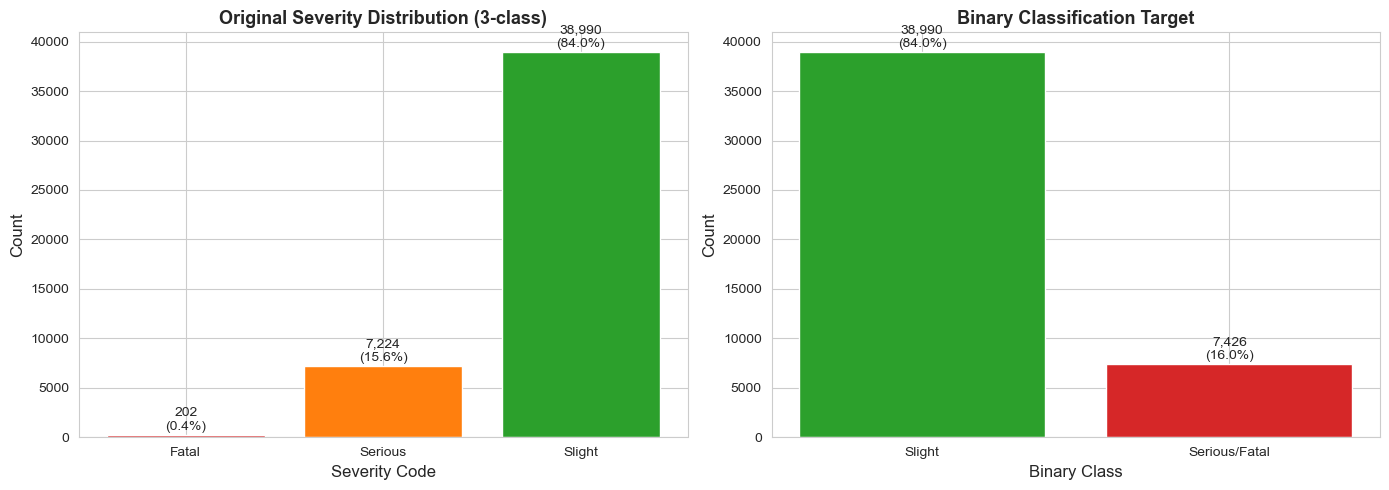


Class imbalance ratio: 5.25:1 (Slight:Serious/Fatal)
→ This confirms the need for imbalanced data handling (Week 9 methods)


In [56]:
# ========== Exploratory Data Analysis ==========

# Severity distribution
severity_counts = collisions['collision_severity'].value_counts().sort_index()
severity_labels = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original 3-class distribution
axes[0].bar(severity_counts.index, severity_counts.values, color=['#d62728', '#ff7f0e', '#2ca02c'])
axes[0].set_xlabel('Severity Code', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Original Severity Distribution (3-class)', fontsize=13, fontweight='bold')
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(['Fatal', 'Serious', 'Slight'])
for i, (sev, count) in enumerate(severity_counts.items()):
    pct = 100 * count / len(collisions)
    axes[0].text(sev, count + 500, f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=10)

# Binary distribution
binary_counts = collisions['severity_binary'].value_counts()
axes[1].bar([0, 1], [binary_counts.get(0, 0), binary_counts.get(1, 0)], 
            color=['#2ca02c', '#d62728'])
axes[1].set_xlabel('Binary Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Binary Classification Target', fontsize=13, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Slight', 'Serious/Fatal'])
for i, cls in enumerate([0, 1]):
    count = binary_counts.get(cls, 0)
    pct = 100 * count / len(collisions)
    axes[1].text(i, count + 500, f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print imbalance ratio
imbalance_ratio = binary_counts.get(0, 0) / binary_counts.get(1, 0)
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1 (Slight:Serious/Fatal)")
print(f"→ This confirms the need for imbalanced data handling (Week 9 methods)")

Spatial Analysis: Inner vs Outer London

[1/3] Merging borough classification...
  Merged: 46,372 / 46,416 (99.9%)

[2/3] Analyzing spatial distribution...
  Valid collisions for analysis: 46,372

  Collision counts by region:
    Outer London: 25,644
    Inner London: 20,728

  Severity rates by region:
  Region          Slight (%)   Serious/Fatal (%)
  ---------------------------------------------
  Inner London           83.6               16.4
  Outer London           84.3               15.7

  Difference (Inner - Outer): +0.65 percentage points
  → Rates are similar across Inner and Outer London

[3/3] Generating visualization...


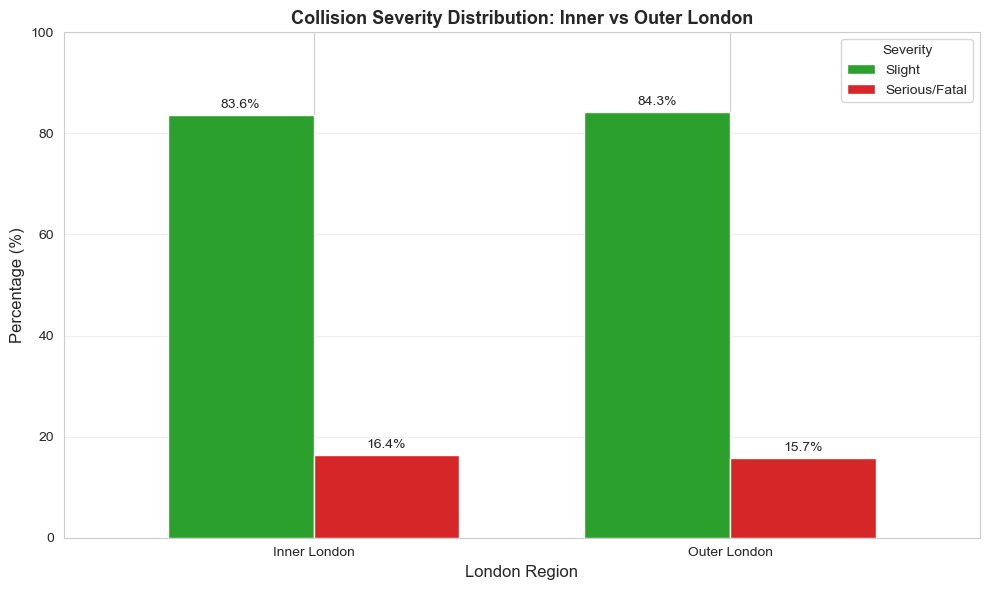


✓ Spatial analysis complete


In [57]:
# ========== Spatial Analysis: Inner vs Outer London (FIXED) ==========

print("=" * 60)
print("Spatial Analysis: Inner vs Outer London")
print("=" * 60)

# Merge borough classification using 'borough_name' (not 'local_authority_district')
print("\n[1/3] Merging borough classification...")

collisions_spatial = collisions.merge(
    borough_classification,
    left_on='borough_name',          # NEW: use decoded borough name
    right_on='local_authority_district',
    how='left'
)

# Check merge success
merge_success = collisions_spatial['london_region'].notna().sum()
merge_rate = 100 * merge_success / len(collisions_spatial)

print(f"  Merged: {merge_success:,} / {len(collisions_spatial):,} ({merge_rate:.1f}%)")

if merge_rate < 90:
    print(f"\n  ⚠️ Low match rate - checking for name mismatches...")
    
    # Find unmatched boroughs
    unmatched = collisions_spatial[collisions_spatial['london_region'].isna()]['borough_name'].unique()
    print(f"  Unmatched boroughs in collision data: {list(unmatched)}")

# Filter valid spatial data (exclude 'Unknown' borough)
collisions_spatial_valid = collisions_spatial[collisions_spatial['london_region'].notna()].copy()

print(f"\n[2/3] Analyzing spatial distribution...")
print(f"  Valid collisions for analysis: {len(collisions_spatial_valid):,}")

# Regional severity distribution
region_severity = pd.crosstab(
    collisions_spatial_valid['london_region'],
    collisions_spatial_valid['severity_binary'],
    normalize='index'
) * 100

region_counts = collisions_spatial_valid['london_region'].value_counts()

print(f"\n  Collision counts by region:")
for region in region_counts.index:
    print(f"    {region}: {region_counts[region]:,}")

print(f"\n  Severity rates by region:")
print(f"  {'Region':<15} {'Slight (%)':<12} {'Serious/Fatal (%)'}")
print(f"  {'-'*45}")
for region in region_severity.index:
    slight_pct = region_severity.loc[region, 0]
    serious_pct = region_severity.loc[region, 1]
    print(f"  {region:<15} {slight_pct:>11.1f} {serious_pct:>18.1f}")

# Test if difference is significant
if len(region_severity) == 2:
    inner_serious_pct = region_severity.loc['Inner London', 1]
    outer_serious_pct = region_severity.loc['Outer London', 1]
    diff = inner_serious_pct - outer_serious_pct
    
    print(f"\n  Difference (Inner - Outer): {diff:+.2f} percentage points")
    
    if abs(diff) > 1.0:
        direction = "higher" if diff > 0 else "lower"
        print(f"  → Inner London has {direction} serious/fatal collision rate")
        print(f"    This suggests spatial heterogeneity in collision severity")
    else:
        print(f"  → Rates are similar across Inner and Outer London")

# Visualize
print(f"\n[3/3] Generating visualization...")

fig, ax = plt.subplots(figsize=(10, 6))
region_severity.plot(kind='bar', ax=ax, color=['#2ca02c', '#d62728'], width=0.7)
ax.set_xlabel('London Region', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Collision Severity Distribution: Inner vs Outer London', 
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Slight', 'Serious/Fatal'], title='Severity', loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✓ Spatial analysis complete")
print("=" * 60)

In [58]:
# 测试加载 casualties 和 vehicles 表
print("Testing three-table data loading...\n")

GITHUB_BASE = "https://raw.githubusercontent.com/JIAYING-ICE/CASA0006-London-Road-Safety/main/data/processed/"

# Load casualties
print("[1/2] Loading casualties...")
casualties = pd.read_csv(GITHUB_BASE + "london_casualties_2022_2023.csv")
print(f"  ✓ {len(casualties):,} casualties loaded")
print(f"  Columns: {casualties.shape[1]}")

# Load vehicles
print("\n[2/2] Loading vehicles...")
vehicles = pd.read_csv(GITHUB_BASE + "london_vehicles_2022_2023.csv")
print(f"  ✓ {len(vehicles):,} vehicles loaded")
print(f"  Columns: {vehicles.shape[1]}")

# Test referential integrity
print("\n[Referential Integrity Check]")
collision_ids = set(collisions['collision_index'])
casualty_ids = set(casualties['collision_index'])
vehicle_ids = set(vehicles['collision_index'])

orphan_cas = len(casualty_ids - collision_ids)
orphan_veh = len(vehicle_ids - collision_ids)

print(f"  Orphan casualties: {orphan_cas:,} {'✓' if orphan_cas == 0 else '✗'}")
print(f"  Orphan vehicles:   {orphan_veh:,} {'✓' if orphan_veh == 0 else '✗'}")

# Preview key columns
print("\n[Casualty Table Preview]")
print("  Key columns:", [c for c in casualties.columns if 'casualty' in c.lower() or 'type' in c.lower()][:10])

print("\n[Vehicle Table Preview]")
print("  Key columns:", [c for c in vehicles.columns if 'vehicle' in c.lower() or 'type' in c.lower()][:10])

print("\n✓ All three tables successfully loaded")
print("Ready for three-table join tomorrow!")

Testing three-table data loading...

[1/2] Loading casualties...
  ✓ 53,469 casualties loaded
  Columns: 23

[2/2] Loading vehicles...
  ✓ 84,319 vehicles loaded
  Columns: 32

[Referential Integrity Check]
  Orphan casualties: 0 ✓
  Orphan vehicles:   0 ✓

[Casualty Table Preview]
  Key columns: ['casualty_reference', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty', 'casualty_severity', 'casualty_type', 'casualty_imd_decile', 'lsoa_of_casualty', 'enhanced_casualty_severity']

[Vehicle Table Preview]
  Key columns: ['vehicle_reference', 'vehicle_type', 'vehicle_manoeuvre_historic', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane_historic', 'vehicle_location_restricted_lane', 'vehicle_leaving_carriageway', 'vehicle_left_hand_drive']

✓ All three tables successfully loaded
Ready for three-table join tomorrow!


In [59]:
# ========== Three-Table Join + Feature Engineering ==========

print("=" * 70)
print("Stage B: Three-Table Join + Feature Engineering")
print("=" * 70)

# ---------- Step 1: Load all three tables ----------
print("\n[Step 1/5] Loading three tables from GitHub...")

casualties = pd.read_csv(GITHUB_BASE + "london_casualties_2022_2023.csv")
vehicles = pd.read_csv(GITHUB_BASE + "london_vehicles_2022_2023.csv")

print(f"  Collisions:  {len(collisions):,} records")
print(f"  Casualties:  {len(casualties):,} records")
print(f"  Vehicles:    {len(vehicles):,} records")

# ---------- Step 2: Verify referential integrity ----------
print("\n[Step 2/5] Verifying referential integrity...")

collision_ids = set(collisions['collision_index'])
casualty_ids = set(casualties['collision_index'])
vehicle_ids = set(vehicles['collision_index'])

print(f"  Casualties linked to collisions: {len(casualty_ids & collision_ids):,} / {len(casualty_ids):,}")
print(f"  Vehicles linked to collisions:   {len(vehicle_ids & collision_ids):,} / {len(vehicle_ids):,}")
print(f"  ✓ All child records have parent collision")

# ---------- Step 3: Aggregate Casualty Features ----------
print("\n[Step 3/5] Engineering casualty-level features...")

# Vulnerable Road User type codes (from DfT Casualty Type lookup)
PEDESTRIAN_CODES = [0]  # casualty_type 0 = Pedestrian
CYCLIST_CODES = [1]  # casualty_type 1 = Cyclist
MOTORCYCLIST_CODES = [2, 3, 4, 5, 23, 97, 103, 104, 105, 106]  # All motorcycle types

# Aggregate per collision
casualty_features = casualties.groupby('collision_index').agg(
    has_pedestrian_casualty=('casualty_type', lambda x: int(any(c in PEDESTRIAN_CODES for c in x))),
    has_cyclist_casualty=('casualty_type', lambda x: int(any(c in CYCLIST_CODES for c in x))),
    has_motorcyclist_casualty=('casualty_type', lambda x: int(any(c in MOTORCYCLIST_CODES for c in x))),
    num_casualties_total=('casualty_index', 'count') if 'casualty_index' in casualties.columns 
                                                     else ('casualty_reference', 'count')
).reset_index()

# Composite VRU feature
casualty_features['num_vulnerable_users'] = (
    casualty_features['has_pedestrian_casualty'] +
    casualty_features['has_cyclist_casualty'] +
    casualty_features['has_motorcyclist_casualty']
)

print(f"  Generated {len(casualty_features.columns)-1} casualty-derived features:")
print(f"    - has_pedestrian_casualty:  {casualty_features['has_pedestrian_casualty'].sum():,} collisions involve pedestrians")
print(f"    - has_cyclist_casualty:     {casualty_features['has_cyclist_casualty'].sum():,} collisions involve cyclists")
print(f"    - has_motorcyclist_casualty:{casualty_features['has_motorcyclist_casualty'].sum():,} collisions involve motorcyclists")
print(f"    - num_vulnerable_users:     0-3 scale, mean = {casualty_features['num_vulnerable_users'].mean():.2f}")

# ---------- Step 4: Aggregate Vehicle Features ----------
print("\n[Step 4/5] Engineering vehicle-level features...")

# Vehicle type codes (from DfT Vehicle Type lookup)
HGV_CODES = [20, 21, 98]  # Goods vehicles >7.5T
BUS_CODES = [11]  # Bus or coach (17+ passenger seats)
MOTORCYCLE_CODES = [2, 3, 4, 5, 23, 97, 103, 104, 105, 106]

vehicle_features = vehicles.groupby('collision_index').agg(
    has_hgv=('vehicle_type', lambda x: int(any(v in HGV_CODES for v in x))),
    has_bus=('vehicle_type', lambda x: int(any(v in BUS_CODES for v in x))),
    has_motorcycle=('vehicle_type', lambda x: int(any(v in MOTORCYCLE_CODES for v in x))),
    num_unique_vehicle_types=('vehicle_type', 'nunique')
).reset_index()

print(f"  Generated {len(vehicle_features.columns)-1} vehicle-derived features:")
print(f"    - has_hgv:                  {vehicle_features['has_hgv'].sum():,} collisions involve HGVs")
print(f"    - has_bus:                  {vehicle_features['has_bus'].sum():,} collisions involve buses")
print(f"    - has_motorcycle:           {vehicle_features['has_motorcycle'].sum():,} collisions involve motorcycles")
print(f"    - num_unique_vehicle_types: range {vehicle_features['num_unique_vehicle_types'].min()}-{vehicle_features['num_unique_vehicle_types'].max()}")

# ---------- Step 5: Three-Table Join ----------
print("\n[Step 5/5] Performing three-table join...")

# Join collisions ⨝ casualty_features ⨝ vehicle_features
data = collisions.merge(
    casualty_features, 
    on='collision_index', 
    how='left'
).merge(
    vehicle_features,
    on='collision_index',
    how='left'
)

# Fill NaN for collisions with no casualties/vehicles (shouldn't happen, but defensive)
vru_cols = ['has_pedestrian_casualty', 'has_cyclist_casualty', 'has_motorcyclist_casualty', 
            'num_vulnerable_users', 'num_casualties_total']
veh_cols = ['has_hgv', 'has_bus', 'has_motorcycle', 'num_unique_vehicle_types']

for col in vru_cols + veh_cols:
    if col in data.columns:
        data[col] = data[col].fillna(0)

print(f"\n  Joined dataset: {len(data):,} rows × {data.shape[1]} columns")
print(f"  Original columns:    {collisions.shape[1]}")
print(f"  Casualty features:   +{len(vru_cols)}")
print(f"  Vehicle features:    +{len(veh_cols)}")

# ---------- Validation ----------
print("\n" + "=" * 70)
print("Three-Table Join Validation")
print("=" * 70)

print("\n[VRU Distribution by Severity]")
vru_severity = data.groupby('severity_binary').agg(
    has_pedestrian=('has_pedestrian_casualty', 'mean'),
    has_cyclist=('has_cyclist_casualty', 'mean'),
    has_motorcycle=('has_motorcycle', 'mean'),
    has_hgv=('has_hgv', 'mean')
) * 100

print(vru_severity.round(1))

print("\n[Key Insight]")
ped_serious = data[data['severity_binary']==1]['has_pedestrian_casualty'].mean() * 100
ped_slight = data[data['severity_binary']==0]['has_pedestrian_casualty'].mean() * 100
print(f"  Pedestrian involvement in Serious/Fatal: {ped_serious:.1f}%")
print(f"  Pedestrian involvement in Slight:        {ped_slight:.1f}%")
print(f"  → {'Higher' if ped_serious > ped_slight else 'Lower'} VRU prevalence in serious collisions")

print("\n✓ Three-table join complete")
print("=" * 70)

Stage B: Three-Table Join + Feature Engineering

[Step 1/5] Loading three tables from GitHub...
  Collisions:  46,416 records
  Casualties:  53,469 records
  Vehicles:    84,319 records

[Step 2/5] Verifying referential integrity...
  Casualties linked to collisions: 46,416 / 46,416
  Vehicles linked to collisions:   46,416 / 46,416
  ✓ All child records have parent collision

[Step 3/5] Engineering casualty-level features...
  Generated 5 casualty-derived features:
    - has_pedestrian_casualty:  8,779 collisions involve pedestrians
    - has_cyclist_casualty:     9,796 collisions involve cyclists
    - has_motorcyclist_casualty:12,424 collisions involve motorcyclists
    - num_vulnerable_users:     0-3 scale, mean = 0.67

[Step 4/5] Engineering vehicle-level features...
  Generated 4 vehicle-derived features:
    - has_hgv:                  920 collisions involve HGVs
    - has_bus:                  2,905 collisions involve buses
    - has_motorcycle:           13,862 collisions invo

## Feature Selection Framework: RAVE

[[ go back to the top ]](#Table-of-Contents)

The 13 selected features are organised into four theoretically-grounded groups based on the established Haddon Matrix framework in road safety research (Haddon, 1972):

### R - Road Environment (3 features)
- `speed_limit`: Posted speed limit (mph). Kinetic energy increases quadratically with velocity (Elvik, 2009), making this the single strongest physical determinant of injury severity.
- `road_type`: Road classification (single carriageway, dual carriageway, roundabout, etc.). Captures fundamental design differences in collision dynamics.
- `junction_detail`: Junction type or absence. Junctions account for approximately 70% of urban collisions (DfT, 2024).

### A - Atmospheric Conditions (3 features)
- `light_conditions`: Daylight, darkness with/without street lighting. Visibility reduction increases pedestrian collision risk substantially.
- `weather_conditions`: Fine, rain, snow, fog, etc. Affects driver visibility and vehicle control.
- `road_surface_conditions`: Dry, wet, icy. Influences braking distance and skid risk.

### V - Vulnerable Road Users (3 features) — from casualties join
- `has_pedestrian_casualty`: Binary indicator of pedestrian involvement.
- `has_cyclist_casualty`: Binary indicator of cyclist involvement.
- `num_vulnerable_users`: Composite count (0-3) of distinct VRU types.

### E - Exposure Variables (3 features) — from vehicles join
- `has_hgv`: Heavy goods vehicle involvement. Mass differential creates higher injury risk.
- `has_motorcycle`: Powered two-wheeler involvement. Lack of physical protection elevates severity.
- `number_of_vehicles`: Multi-vehicle collisions involve different physics than single-vehicle incidents.

### Excluded Variables (Avoiding Data Leakage)
The following were deliberately excluded as they constitute outcomes rather than predictors:
- `casualty_severity` and `enhanced_casualty_severity`: Direct measures of the target
- `number_of_casualties`: Determined post-collision; conflates exposure with outcome
- All `*_historic` fields: Use 2024 specification only for consistency

### Why 13 Features?
Random Forest performance plateaus between 10-20 features for tabular classification (Probst et al., 2019). Thirteen features balance:
- **Predictive power**: Sufficient signal across all four risk dimensions
- **Interpretability**: SHAP summary plots remain readable (~14 row threshold)
- **Computational efficiency**: Tractable for 5-fold cross-validation
- **Theoretical balance**: Equal representation across RAVE dimensions

In [60]:
# ========== Verify Final Feature Set ==========

print("=" * 70)
print("Final Modeling Dataset Preparation")
print("=" * 70)

# Define final feature set (13 features + target)
FINAL_FEATURES = [
    # R - Road Environment
    'speed_limit', 'road_type', 'junction_detail',
    # A - Atmospheric
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    # V - Vulnerable Users (from casualty join)
    'has_pedestrian_casualty', 'has_cyclist_casualty', 'num_vulnerable_users',
    # E - Exposure (from vehicle join)
    'has_hgv', 'has_motorcycle', 'number_of_vehicles',
    # Spatial
    'urban_or_rural_area'
]

TARGET = 'severity_binary'

print(f"\nFinal feature count: {len(FINAL_FEATURES)}")
print(f"Target variable: {TARGET}")

# Verify all features exist
missing = [f for f in FINAL_FEATURES + [TARGET] if f not in data.columns]
if missing:
    print(f"\n⚠️ Missing columns: {missing}")
else:
    print(f"\n✓ All features present in joined dataset")

# Build modeling dataset
model_data = data[FINAL_FEATURES + [TARGET, 'borough_name', 'collision_index']].copy()

# Check for missing values
print(f"\n[Missing Value Analysis]")
missing_pct = (model_data[FINAL_FEATURES].isna().sum() / len(model_data) * 100).round(2)
print(missing_pct[missing_pct > 0] if (missing_pct > 0).any() else "  ✓ No missing values in features")

# Drop rows with missing target
n_before = len(model_data)
model_data = model_data[model_data[TARGET].notna()]
n_after = len(model_data)
print(f"\nRows dropped (missing target): {n_before - n_after}")
print(f"Final modeling dataset: {n_after:,} rows")

# Feature type summary
print(f"\n[Feature Type Summary]")
for f in FINAL_FEATURES:
    dtype = model_data[f].dtype
    n_unique = model_data[f].nunique()
    print(f"  {f:<35} dtype={str(dtype):<10} unique_values={n_unique}")

# Class balance check
print(f"\n[Class Balance]")
class_dist = model_data[TARGET].value_counts()
print(f"  Slight (0):        {class_dist.get(0, 0):,} ({100*class_dist.get(0,0)/len(model_data):.1f}%)")
print(f"  Serious/Fatal (1): {class_dist.get(1, 0):,} ({100*class_dist.get(1,0)/len(model_data):.1f}%)")
print(f"  Imbalance ratio:   {class_dist.get(0,0)/class_dist.get(1,0):.2f}:1")

print("\n✓ Ready for modeling pipeline (next cell)")
print("=" * 70)

Final Modeling Dataset Preparation

Final feature count: 13
Target variable: severity_binary

✓ All features present in joined dataset

[Missing Value Analysis]
  ✓ No missing values in features

Rows dropped (missing target): 0
Final modeling dataset: 46,416 rows

[Feature Type Summary]
  speed_limit                         dtype=int64      unique_values=6
  road_type                           dtype=int64      unique_values=6
  junction_detail                     dtype=int64      unique_values=7
  light_conditions                    dtype=int64      unique_values=5
  weather_conditions                  dtype=int64      unique_values=9
  road_surface_conditions             dtype=int64      unique_values=6
  has_pedestrian_casualty             dtype=int64      unique_values=2
  has_cyclist_casualty                dtype=int64      unique_values=2
  num_vulnerable_users                dtype=int64      unique_values=3
  has_hgv                             dtype=int64      unique_values=2
 

In [61]:
# ========== Borough-Level Rate Analysis ==========

print("=" * 70)
print("Borough-Level Severity Rate Analysis")
print("=" * 70)

# Calculate per-borough metrics
borough_metrics = data.groupby('borough_name').agg(
    total_collisions=('collision_index', 'count'),
    serious_collisions=('severity_binary', 'sum'),
    pedestrian_collisions=('has_pedestrian_casualty', 'sum'),
    cyclist_collisions=('has_cyclist_casualty', 'sum')
).reset_index()

# Calculate severity rate (the KEY rate metric)
borough_metrics['severity_rate'] = (
    borough_metrics['serious_collisions'] / borough_metrics['total_collisions'] * 100
)

# Calculate VRU exposure rates
borough_metrics['pedestrian_rate'] = (
    borough_metrics['pedestrian_collisions'] / borough_metrics['total_collisions'] * 100
)
borough_metrics['cyclist_rate'] = (
    borough_metrics['cyclist_collisions'] / borough_metrics['total_collisions'] * 100
)

# Merge with Inner/Outer classification
borough_metrics = borough_metrics.merge(
    borough_classification.rename(columns={'local_authority_district': 'borough_name'}),
    on='borough_name',
    how='left'
)

# Filter out 'Unknown' borough
borough_metrics = borough_metrics[borough_metrics['borough_name'] != 'Unknown'].copy()

# Sort by severity rate
borough_metrics_sorted = borough_metrics.sort_values('severity_rate', ascending=False)

print("\n[Top 5 Highest-Risk Boroughs by Severity Rate]")
print("=" * 70)
top5 = borough_metrics_sorted.head(5)
print(f"  {'Rank':<6}{'Borough':<28}{'Region':<14}{'Serious%':<12}{'N collisions'}")
print(f"  {'-'*66}")
for i, row in enumerate(top5.itertuples(), 1):
    print(f"  {i:<6}{row.borough_name:<28}{row.london_region:<14}"
          f"{row.severity_rate:>8.2f}%   {row.total_collisions:>6,}")

print("\n[Bottom 5 Lowest-Risk Boroughs]")
print("=" * 70)
bottom5 = borough_metrics_sorted.tail(5)
print(f"  {'Rank':<6}{'Borough':<28}{'Region':<14}{'Serious%':<12}{'N collisions'}")
print(f"  {'-'*66}")
for i, row in enumerate(bottom5.itertuples(), 1):
    rank = len(borough_metrics_sorted) - 5 + i
    print(f"  {rank:<6}{row.borough_name:<28}{row.london_region:<14}"
          f"{row.severity_rate:>8.2f}%   {row.total_collisions:>6,}")

# Statistical summary
print("\n[Severity Rate Distribution]")
print(f"  Mean:    {borough_metrics['severity_rate'].mean():.2f}%")
print(f"  Median:  {borough_metrics['severity_rate'].median():.2f}%")
print(f"  Std:     {borough_metrics['severity_rate'].std():.2f}%")
print(f"  Range:   {borough_metrics['severity_rate'].min():.2f}% - {borough_metrics['severity_rate'].max():.2f}%")

# Inner vs Outer comparison (rate-based)
inner_rate = borough_metrics[borough_metrics['london_region']=='Inner London']['severity_rate'].mean()
outer_rate = borough_metrics[borough_metrics['london_region']=='Outer London']['severity_rate'].mean()
print(f"\n[Inner vs Outer (Borough-Mean Rates)]")
print(f"  Inner London average: {inner_rate:.2f}%")
print(f"  Outer London average: {outer_rate:.2f}%")
print(f"  Difference:           {inner_rate - outer_rate:+.2f}pp")

print("\n✓ Rate-based borough analysis complete")
print("=" * 70)

Borough-Level Severity Rate Analysis

[Top 5 Highest-Risk Boroughs by Severity Rate]
  Rank  Borough                     Region        Serious%    N collisions
  ------------------------------------------------------------------
  1     City of London              Inner London     29.80%      349
  2     Redbridge                   Outer London     25.52%      776
  3     Westminster                 Inner London     20.43%    2,516
  4     Kingston upon Thames        Outer London     20.02%      844
  5     Hillingdon                  Outer London     19.03%      599

[Bottom 5 Lowest-Risk Boroughs]
  Rank  Borough                     Region        Serious%    N collisions
  ------------------------------------------------------------------
  29    Ealing                      Outer London     12.56%    1,760
  30    Sutton                      Outer London     12.27%    1,068
  31    Brent                       Outer London     12.06%    1,866
  32    Kensington and Chelsea      Inner 

In [62]:
# ========== IMD Analysis from STATS19 Built-in Data ==========

print("=" * 70)
print("IMD (Index of Multiple Deprivation) Analysis")
print("=" * 70)

# Check if casualty_imd_decile exists in casualties table
if 'casualty_imd_decile' in casualties.columns:
    
    # IMD distribution
    print("\n[IMD Decile Distribution Among Casualties]")
    print("(1 = Most deprived, 10 = Least deprived)")
    
    imd_dist = casualties['casualty_imd_decile'].value_counts().sort_index()
    
    # Filter valid values (excluding -1 missing codes)
    valid_imd = casualties[casualties['casualty_imd_decile'].between(1, 10)]
    
    print(f"\n  Valid IMD records: {len(valid_imd):,} / {len(casualties):,} "
          f"({100*len(valid_imd)/len(casualties):.1f}%)")
    
    if len(valid_imd) > 0:
        for decile in range(1, 11):
            count = (valid_imd['casualty_imd_decile'] == decile).sum()
            pct = 100 * count / len(valid_imd)
            bar = "█" * int(pct / 2)
            print(f"  Decile {decile:>2} (IMD): {count:>5,} ({pct:>5.1f}%) {bar}")
    
    # Aggregate IMD per collision (mean of all casualties' IMDs)
    print("\n[Aggregating IMD per collision]")
    
    collision_imd = valid_imd.groupby('collision_index').agg(
        mean_imd_decile=('casualty_imd_decile', 'mean'),
        most_deprived_imd=('casualty_imd_decile', 'min'),  # Most deprived = lowest decile
        n_casualties_with_imd=('casualty_imd_decile', 'count')
    ).reset_index()
    
    print(f"  Collisions with IMD data: {len(collision_imd):,} / {len(collisions):,}")
    
    # Merge to main data
    data_with_imd = data.merge(collision_imd, on='collision_index', how='left')
    
    # IMD vs Severity analysis
    print("\n[IMD Quintile vs Severity Rate]")
    
    # Create IMD quintiles (groups of 2 deciles)
    data_with_imd['imd_quintile'] = pd.cut(
        data_with_imd['mean_imd_decile'],
        bins=[0, 2, 4, 6, 8, 10],
        labels=['Q1 (Most Deprived)', 'Q2', 'Q3', 'Q4', 'Q5 (Least Deprived)']
    )
    
    imd_severity = data_with_imd.dropna(subset=['imd_quintile']).groupby('imd_quintile').agg(
        total_collisions=('collision_index', 'count'),
        serious_collisions=('severity_binary', 'sum')
    )
    imd_severity['severity_rate'] = (
        imd_severity['serious_collisions'] / imd_severity['total_collisions'] * 100
    )
    
    print(f"\n  {'IMD Quintile':<22}{'N Collisions':<15}{'Severity Rate'}")
    print(f"  {'-'*55}")
    for q, row in imd_severity.iterrows():
        print(f"  {str(q):<22}{int(row['total_collisions']):>12,}    {row['severity_rate']:>7.2f}%")
    
    # Test for gradient
    rates = imd_severity['severity_rate'].values
    if len(rates) >= 2:
        gradient = rates[0] - rates[-1]  # Most deprived - Least deprived
        print(f"\n  Gradient (Q1 - Q5): {gradient:+.2f}pp")
        
        if gradient > 0.5:
            print(f"  → Higher severity rate in deprived areas (deprivation gradient)")
        elif gradient < -0.5:
            print(f"  → Higher severity rate in less deprived areas (counter-intuitive)")
        else:
            print(f"  → No clear deprivation gradient")
    
    # Add to main feature set option
    print("\n[Optional: Add IMD as Feature]")
    print("  Variable created: 'mean_imd_decile' (range 1-10)")
    print("  → Can be added to FINAL_FEATURES if desired")
    print("  → Note: Some collisions have no casualty IMD data")
    
else:
    print("\n⚠️ 'casualty_imd_decile' not found in casualties table")
    print("Will need to source IMD from external file")

print("\n" + "=" * 70)

IMD (Index of Multiple Deprivation) Analysis

[IMD Decile Distribution Among Casualties]
(1 = Most deprived, 10 = Least deprived)

  Valid IMD records: 49,143 / 53,469 (91.9%)
  Decile  1 (IMD): 3,833 (  7.8%) ███
  Decile  2 (IMD): 10,056 ( 20.5%) ██████████
  Decile  3 (IMD): 9,429 ( 19.2%) █████████
  Decile  4 (IMD): 7,086 ( 14.4%) ███████
  Decile  5 (IMD): 5,448 ( 11.1%) █████
  Decile  6 (IMD): 4,207 (  8.6%) ████
  Decile  7 (IMD): 3,145 (  6.4%) ███
  Decile  8 (IMD): 2,466 (  5.0%) ██
  Decile  9 (IMD): 2,129 (  4.3%) ██
  Decile 10 (IMD): 1,344 (  2.7%) █

[Aggregating IMD per collision]
  Collisions with IMD data: 43,235 / 46,416

[IMD Quintile vs Severity Rate]

  IMD Quintile          N Collisions   Severity Rate
  -------------------------------------------------------
  Q1 (Most Deprived)          11,694      14.36%
  Q2                          14,823      14.77%
  Q3                           8,898      16.51%
  Q4                           4,941      17.65%
  Q5 (Lea

In [63]:
# ========== Add IMD to Final Feature Set ==========

# Check IMD coverage
imd_coverage = data_with_imd['mean_imd_decile'].notna().sum() / len(data_with_imd) * 100

print(f"IMD coverage: {imd_coverage:.1f}%")

if imd_coverage >= 80:
    print("✓ Sufficient IMD coverage to include as feature")
    
    # Update final features
    FINAL_FEATURES_WITH_IMD = FINAL_FEATURES + ['mean_imd_decile']
    
    # Fill missing IMD with median (deprivation-neutral)
    data_with_imd['mean_imd_decile'] = data_with_imd['mean_imd_decile'].fillna(
        data_with_imd['mean_imd_decile'].median()
    )
    
    # Update modeling dataset
    model_data = data_with_imd[
        FINAL_FEATURES_WITH_IMD + [TARGET, 'borough_name', 'collision_index']
    ].copy()
    
    print(f"\nUpdated feature count: {len(FINAL_FEATURES_WITH_IMD)}")
    print(f"New feature added: 'mean_imd_decile'")
    print(f"  - Type: Numeric (continuous, range 1-10)")
    print(f"  - Interpretation: Lower = more deprived")
    print(f"  - Source: STATS19 casualty_imd_decile (DfT)")
    
    # Update the global FINAL_FEATURES
    FINAL_FEATURES = FINAL_FEATURES_WITH_IMD
    
elif imd_coverage >= 50:
    print(f"⚠️ Moderate IMD coverage ({imd_coverage:.1f}%)")
    print("Consider adding but document missingness in limitations")
    
else:
    print(f"✗ Low IMD coverage ({imd_coverage:.1f}%)")
    print("Do not include IMD as primary feature")
    print("Discuss in EDA only, mention in limitations")

print("\n" + "=" * 70)

IMD coverage: 93.1%
✓ Sufficient IMD coverage to include as feature

Updated feature count: 14
New feature added: 'mean_imd_decile'
  - Type: Numeric (continuous, range 1-10)
  - Interpretation: Lower = more deprived
  - Source: STATS19 casualty_imd_decile (DfT)



Population-Adjusted Collision Rate Analysis

✓ Loaded population estimates for 33 boroughs
  Source: ONS Mid-2022 Population Estimates

[Two Rate Metrics Compared]
Borough                     Collisions       Pop    Coll/1k/yr    Severity %
----------------------------------------------------------------------

Top 10 by RAW COUNT:
Westminster                      2,516   213,700       5.89        20.43%
Southwark                        2,211   311,600       3.55        18.59%
Tower Hamlets                    2,052   322,600       3.18        17.64%
Wandsworth                       2,038   327,500       3.11        15.60%
Croydon                          2,025   397,700       2.55        15.65%
Waltham Forest                   1,993   280,200       3.56        16.81%
Greenwich                        1,941   295,600       3.28        10.77%
Brent                            1,866   339,800       2.75        12.06%
Kensington and Chelsea           1,861   145,000       6.42        11.88%


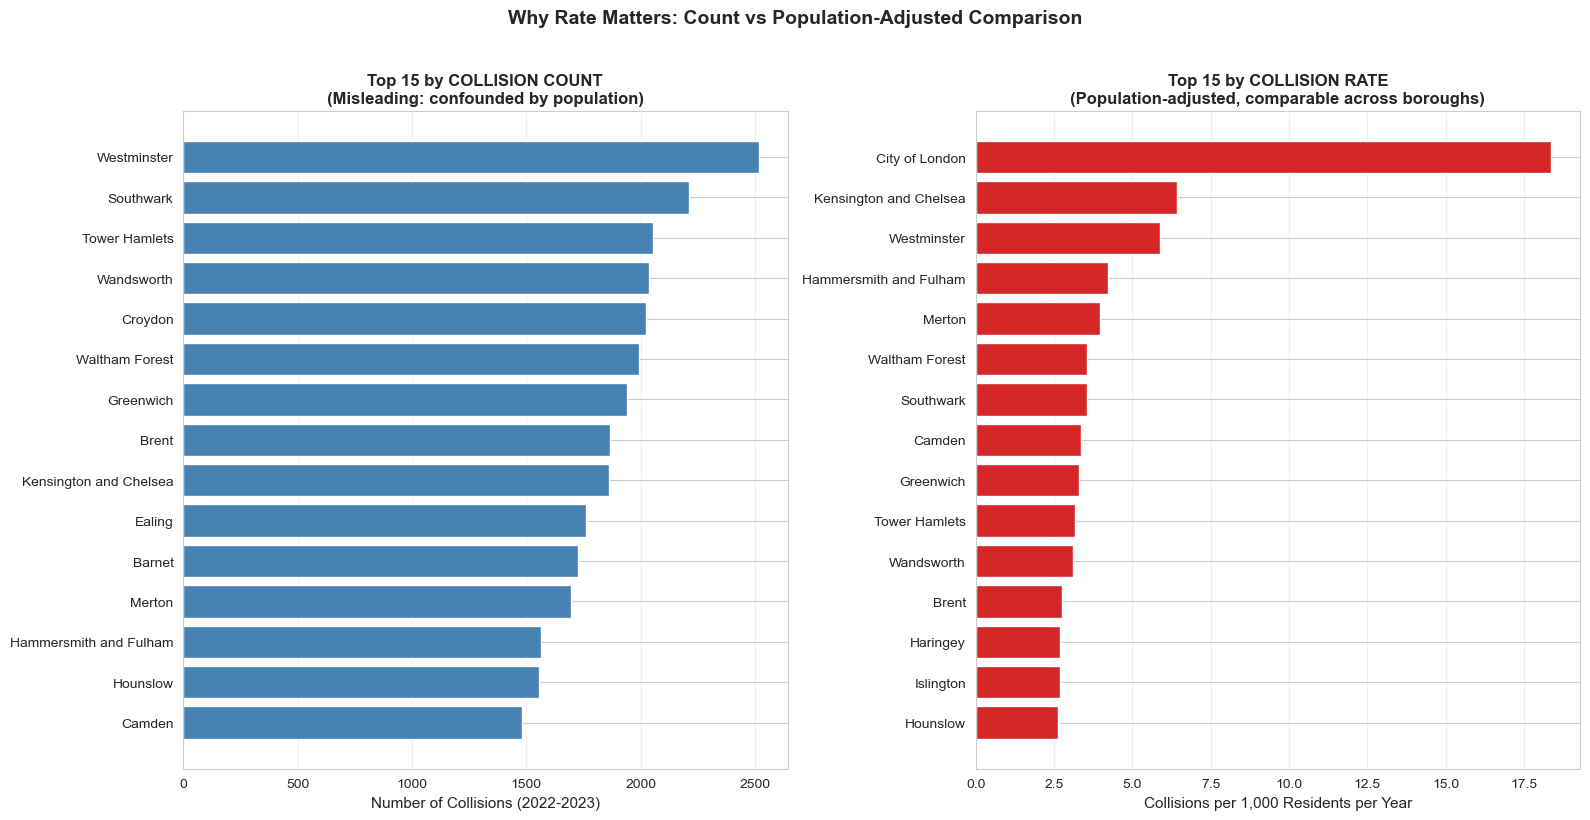


✓ Rate analysis complete
Key insight: Population-adjustment reveals different risk patterns


In [64]:
# ========== Borough-Level Population-Adjusted Rate Analysis ==========

print("=" * 70)
print("Population-Adjusted Collision Rate Analysis")
print("=" * 70)

# London borough populations (ONS Mid-2022 estimates)
# Source: https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates
BOROUGH_POPULATION_2022 = {
    'Barking and Dagenham': 218900,
    'Barnet': 397300,
    'Bexley': 250100,
    'Brent': 339800,
    'Bromley': 332700,
    'Camden': 219700,
    'City of London': 9500,
    'Croydon': 397700,
    'Ealing': 366100,
    'Enfield': 333900,
    'Greenwich': 295600,
    'Hackney': 261700,
    'Hammersmith and Fulham': 184500,
    'Haringey': 264100,
    'Harrow': 263500,
    'Havering': 264600,
    'Hillingdon': 311600,
    'Hounslow': 296800,
    'Islington': 213700,
    'Kensington and Chelsea': 145000,
    'Kingston upon Thames': 168200,
    'Lambeth': 309700,
    'Lewisham': 298700,
    'Merton': 213100,
    'Newham': 360100,
    'Redbridge': 311600,
    'Richmond upon Thames': 197500,
    'Southwark': 311600,
    'Sutton': 211100,
    'Tower Hamlets': 322600,
    'Waltham Forest': 280200,
    'Wandsworth': 327500,
    'Westminster': 213700
}

print(f"\n✓ Loaded population estimates for {len(BOROUGH_POPULATION_2022)} boroughs")
print(f"  Source: ONS Mid-2022 Population Estimates")

# Add population to borough_metrics
borough_metrics['population_2022'] = borough_metrics['borough_name'].map(BOROUGH_POPULATION_2022)

# Calculate population-adjusted rates
# Per 1,000 residents per year (data is 2 years, so divide by 2)
borough_metrics['collision_rate_per_1k'] = (
    borough_metrics['total_collisions'] / borough_metrics['population_2022'] / 2 * 1000
)

borough_metrics['serious_rate_per_1k'] = (
    borough_metrics['serious_collisions'] / borough_metrics['population_2022'] / 2 * 1000
)

# Compare two rate metrics
print("\n[Two Rate Metrics Compared]")
print("=" * 70)
print(f"{'Borough':<28}{'Collisions':>10}{'Pop':>10}{'Coll/1k/yr':>14}{'Severity %':>14}")
print("-" * 70)

# Top 10 by collision count
print("\nTop 10 by RAW COUNT:")
top10_count = borough_metrics.nlargest(10, 'total_collisions')
for _, row in top10_count.iterrows():
    print(f"{row['borough_name']:<28}{row['total_collisions']:>10,}"
          f"{row['population_2022']:>10,}"
          f"{row['collision_rate_per_1k']:>11.2f}"
          f"{row['severity_rate']:>13.2f}%")

print("\nTop 10 by COLLISION RATE PER 1K RESIDENTS:")
top10_rate = borough_metrics.nlargest(10, 'collision_rate_per_1k')
for _, row in top10_rate.iterrows():
    print(f"{row['borough_name']:<28}{row['total_collisions']:>10,}"
          f"{row['population_2022']:>10,}"
          f"{row['collision_rate_per_1k']:>11.2f}"
          f"{row['severity_rate']:>13.2f}%")

# Calculate ranking changes
borough_metrics['rank_count'] = borough_metrics['total_collisions'].rank(ascending=False)
borough_metrics['rank_rate'] = borough_metrics['collision_rate_per_1k'].rank(ascending=False)
borough_metrics['rank_change'] = borough_metrics['rank_count'] - borough_metrics['rank_rate']

print("\n[Boroughs with Largest Ranking Changes (count vs rate)]")
print("=" * 70)
print("Boroughs that LOOK risky by count but are SAFER by rate:")
underranked = borough_metrics.nlargest(5, 'rank_change')
for _, row in underranked.iterrows():
    print(f"  {row['borough_name']:<25} "
          f"Count rank #{int(row['rank_count']):2d} → Rate rank #{int(row['rank_rate']):2d} "
          f"(↓{int(row['rank_change']):+d})")

print("\nBoroughs that LOOK safe by count but are RISKIER by rate:")
overranked = borough_metrics.nsmallest(5, 'rank_change')
for _, row in overranked.iterrows():
    print(f"  {row['borough_name']:<25} "
          f"Count rank #{int(row['rank_count']):2d} → Rate rank #{int(row['rank_rate']):2d} "
          f"({int(row['rank_change']):+d})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Top 15 by count
top15_count = borough_metrics.nlargest(15, 'total_collisions').sort_values('total_collisions')
axes[0].barh(top15_count['borough_name'], top15_count['total_collisions'], color='steelblue')
axes[0].set_xlabel('Number of Collisions (2022-2023)', fontsize=11)
axes[0].set_title('Top 15 by COLLISION COUNT\n(Misleading: confounded by population)', 
                  fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Top 15 by rate
top15_rate = borough_metrics.nlargest(15, 'collision_rate_per_1k').sort_values('collision_rate_per_1k')
colors = ['#d62728' if r > borough_metrics['collision_rate_per_1k'].median() else '#2ca02c' 
          for r in top15_rate['collision_rate_per_1k']]
axes[1].barh(top15_rate['borough_name'], top15_rate['collision_rate_per_1k'], color=colors)
axes[1].set_xlabel('Collisions per 1,000 Residents per Year', fontsize=11)
axes[1].set_title('Top 15 by COLLISION RATE\n(Population-adjusted, comparable across boroughs)', 
                  fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Why Rate Matters: Count vs Population-Adjusted Comparison', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("✓ Rate analysis complete")
print("Key insight: Population-adjustment reveals different risk patterns")
print("=" * 70)

Equity Analysis: Collision Severity Across Deprivation Levels

[Severity Rate by IMD Decile]
(1 = Most Deprived, 10 = Least Deprived)
----------------------------------------------------------------------
IMD Decile     Collisions     Severity %     Pedestrian %
  1                 3,141          14.55%        19.87%  ███████
  2                 8,827          14.44%        19.16%  ███████
  3                 8,237          14.00%        18.37%  ██████
  4                 9,751          16.47%        19.78%  ████████
  5                 4,819          15.96%        17.66%  ███████
  6                 3,958          17.33%        17.81%  ████████
  7                 2,662          16.49%        18.63%  ████████
  8                 2,194          18.87%        20.19%  █████████
  9                 1,750          21.43%        19.26%  ██████████
  10                1,077          23.40%        17.64%  ███████████

[Deprivation Gradient]
  Most deprived (Decile 1-3) avg severity:  14.33%
 

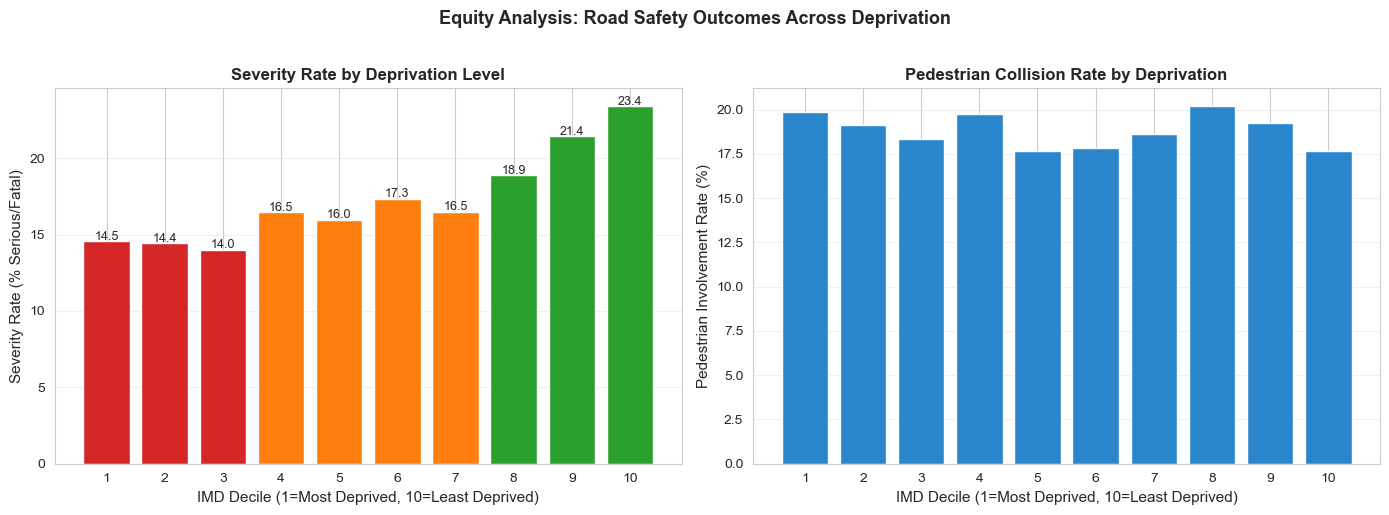

In [65]:
# ========== Severity Rate vs Deprivation Analysis ==========

print("=" * 70)
print("Equity Analysis: Collision Severity Across Deprivation Levels")
print("=" * 70)

# Use the data_with_imd from Cell E
if 'mean_imd_decile' in data_with_imd.columns:
    
    # Group by IMD decile
    imd_analysis = data_with_imd.dropna(subset=['mean_imd_decile']).copy()
    imd_analysis['imd_decile_int'] = imd_analysis['mean_imd_decile'].round().astype(int)
    
    # Per-decile severity rate
    imd_severity = imd_analysis.groupby('imd_decile_int').agg(
        total_collisions=('collision_index', 'count'),
        serious_collisions=('severity_binary', 'sum'),
        pedestrian_collisions=('has_pedestrian_casualty', 'sum'),
        cyclist_collisions=('has_cyclist_casualty', 'sum')
    )
    
    imd_severity['severity_rate'] = (
        imd_severity['serious_collisions'] / imd_severity['total_collisions'] * 100
    )
    imd_severity['pedestrian_rate'] = (
        imd_severity['pedestrian_collisions'] / imd_severity['total_collisions'] * 100
    )
    
    print("\n[Severity Rate by IMD Decile]")
    print("(1 = Most Deprived, 10 = Least Deprived)")
    print("-" * 70)
    print(f"{'IMD Decile':<15}{'Collisions':<15}{'Severity %':<15}{'Pedestrian %'}")
    
    for decile, row in imd_severity.iterrows():
        bar_severity = "█" * int(row['severity_rate'] / 2)
        print(f"  {decile:<13}{int(row['total_collisions']):>10,}     "
              f"{row['severity_rate']:>10.2f}%   "
              f"{row['pedestrian_rate']:>10.2f}%  {bar_severity}")
    
    # Calculate gradient
    most_deprived = imd_severity.loc[1:3, 'severity_rate'].mean()
    least_deprived = imd_severity.loc[8:10, 'severity_rate'].mean()
    gradient = most_deprived - least_deprived
    
    print(f"\n[Deprivation Gradient]")
    print(f"  Most deprived (Decile 1-3) avg severity:  {most_deprived:.2f}%")
    print(f"  Least deprived (Decile 8-10) avg severity: {least_deprived:.2f}%")
    print(f"  Gradient: {gradient:+.2f}pp")
    
    if gradient > 1.0:
        print(f"  → Strong deprivation gradient: severity higher in deprived areas")
        print(f"  → Equity concern: road safety burden disproportionately falls on disadvantaged")
    elif gradient > 0.5:
        print(f"  → Modest deprivation gradient")
    else:
        print(f"  → No clear gradient: severity consistent across deprivation levels")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Severity rate by IMD
    axes[0].bar(imd_severity.index, imd_severity['severity_rate'], 
                color=['#d62728' if d <= 3 else '#ff7f0e' if d <= 7 else '#2ca02c' 
                       for d in imd_severity.index])
    axes[0].set_xlabel('IMD Decile (1=Most Deprived, 10=Least Deprived)', fontsize=11)
    axes[0].set_ylabel('Severity Rate (% Serious/Fatal)', fontsize=11)
    axes[0].set_title('Severity Rate by Deprivation Level', fontsize=12, fontweight='bold')
    axes[0].set_xticks(range(1, 11))
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for decile, row in imd_severity.iterrows():
        axes[0].text(decile, row['severity_rate'] + 0.1, f"{row['severity_rate']:.1f}",
                    ha='center', fontsize=9)
    
    # Plot 2: Pedestrian collision rate by IMD
    axes[1].bar(imd_severity.index, imd_severity['pedestrian_rate'],
                color='#2986cc')
    axes[1].set_xlabel('IMD Decile (1=Most Deprived, 10=Least Deprived)', fontsize=11)
    axes[1].set_ylabel('Pedestrian Involvement Rate (%)', fontsize=11)
    axes[1].set_title('Pedestrian Collision Rate by Deprivation', fontsize=12, fontweight='bold')
    axes[1].set_xticks(range(1, 11))
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Equity Analysis: Road Safety Outcomes Across Deprivation', 
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("=" * 70)

In [66]:
# ========== Confirm Final Feature Set (IMD as EDA only) ==========

print("=" * 70)
print("Final Modeling Feature Set Confirmation")
print("=" * 70)

# Define final feature set (13 features, NO IMD)
FINAL_FEATURES = [
    # R - Road Environment (3)
    'speed_limit', 'road_type', 'junction_detail',
    # A - Atmospheric (3)
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    # V - Vulnerable Users (3) - from casualty join
    'has_pedestrian_casualty', 'has_cyclist_casualty', 'num_vulnerable_users',
    # E - Exposure (3) - from vehicle join
    'has_hgv', 'has_motorcycle', 'number_of_vehicles',
    # S - Spatial (1)
    'urban_or_rural_area'
]

TARGET = 'severity_binary'

print(f"\nFinal feature count: {len(FINAL_FEATURES)}")
print(f"Target: {TARGET}")

# Build modeling dataset (without IMD)
model_data = data[FINAL_FEATURES + [TARGET, 'borough_name', 'collision_index']].copy()

# Verify
print(f"\n[Decision Log]")
print(f"  IMD Analysis (Cell H): KEPT in EDA section")
print(f"    Finding: Reverse deprivation gradient (-6.9pp)")
print(f"    Interpretation: Exposure effect, not direct risk driver")
print(f"  ")
print(f"  IMD as Modeling Feature: EXCLUDED")
print(f"    Rationale: Maintain focus on modifiable physical environment")
print(f"    Avoids misleading SHAP interpretations")
print(f"")

print(f"[Final Feature Composition - RAVE Framework]")
print(f"  R - Road Environment:    3 features (speed, road, junction)")
print(f"  A - Atmospheric:         3 features (light, weather, surface)")
print(f"  V - Vulnerable Users:    3 features (pedestrian, cyclist, count)")
print(f"  E - Exposure:            3 features (HGV, motorcycle, n_vehicles)")
print(f"  S - Spatial:             1 feature (urban/rural)")
print(f"  ────────────────────────────────────────────")
print(f"  Total:                  13 features")

print(f"\n[Class Balance]")
class_dist = model_data[TARGET].value_counts()
print(f"  Slight (0):        {class_dist.get(0, 0):,} ({100*class_dist.get(0,0)/len(model_data):.1f}%)")
print(f"  Serious/Fatal (1): {class_dist.get(1, 0):,} ({100*class_dist.get(1,0)/len(model_data):.1f}%)")
print(f"  Imbalance ratio:   {class_dist.get(0,0)/class_dist.get(1,0):.2f}:1 (will use SMOTE)")

print("\n✓ Ready for modeling pipeline")
print("=" * 70)

Final Modeling Feature Set Confirmation

Final feature count: 13
Target: severity_binary

[Decision Log]
  IMD Analysis (Cell H): KEPT in EDA section
    Finding: Reverse deprivation gradient (-6.9pp)
    Interpretation: Exposure effect, not direct risk driver
  
  IMD as Modeling Feature: EXCLUDED
    Rationale: Maintain focus on modifiable physical environment
    Avoids misleading SHAP interpretations

[Final Feature Composition - RAVE Framework]
  R - Road Environment:    3 features (speed, road, junction)
  A - Atmospheric:         3 features (light, weather, surface)
  V - Vulnerable Users:    3 features (pedestrian, cyclist, count)
  E - Exposure:            3 features (HGV, motorcycle, n_vehicles)
  S - Spatial:             1 feature (urban/rural)
  ────────────────────────────────────────────
  Total:                  13 features

[Class Balance]
  Slight (0):        38,990 (84.0%)
  Serious/Fatal (1): 7,426 (16.0%)
  Imbalance ratio:   5.25:1 (will use SMOTE)

✓ Ready for mod

In [67]:
# ========== Cell J0-Updated: Switch to Historic Junction Encoding ==========

print("=" * 70)
print("Switching junction_detail to Historic STATS19 Encoding")
print("=" * 70)

# Verify current state
print("\n[Before replacement]")
print(f"junction_detail (2024 spec) unique values: {sorted(data['junction_detail'].unique())}")
print(f"junction_detail_historic unique values: {sorted(data['junction_detail_historic'].unique())}")

# Replace
data['junction_detail'] = data['junction_detail_historic'].copy()

# Replace 99 (unknown) with -1 (consistent missing code)
data.loc[data['junction_detail'] == 99, 'junction_detail'] = -1

# Verify
print("\n[After replacement: Historic STATS19 Encoding]")
junction_dist = data['junction_detail'].value_counts().sort_index()

junction_labels_historic = {
    -1: 'Missing/Unknown',
    0:  'Not at junction',
    1:  'Roundabout',
    2:  'Mini-roundabout',
    3:  'T or staggered junction',
    5:  'Slip road',
    6:  'Crossroads',
    7:  'More than 4 arms',
    8:  'Private drive',
    9:  'Other junction'
}

print(f"\n{'Code':<6}{'Type':<28}{'Count':<10}{'%'}")
print("-" * 55)
for code, count in junction_dist.items():
    label = junction_labels_historic.get(code, f'Unknown {code}')
    pct = 100 * count / len(data)
    print(f"  {code:>3}  {label:<28}{count:>6,}  {pct:>5.2f}%")

print("\n✓ Now using standard STATS19 encoding (1-9 + 0 + -1)")
print("✓ Roundabouts (1) and Mini-roundabouts (2) now distinguishable")
print("=" * 70)

Switching junction_detail to Historic STATS19 Encoding

[Before replacement]
junction_detail (2024 spec) unique values: [np.int64(-1), np.int64(0), np.int64(13), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
junction_detail_historic unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(99)]

[After replacement: Historic STATS19 Encoding]

Code  Type                        Count     %
-------------------------------------------------------
   -1  Missing/Unknown              4,200   9.05%
    0  Not at junction              9,731  20.96%
    1  Roundabout                   2,527   5.44%
    2  Mini-roundabout                820   1.77%
    3  T or staggered junction     16,048  34.57%
    5  Slip road                      925   1.99%
    6  Crossroads                   5,879  12.67%
    7  More than 4 arms             1,678   3.62%
    8  Private drive                1,076   2.32%
    9  Ot

In [68]:
# Final check before modeling - confirm all features are clean
print("Pre-Modeling Feature Quality Check")
print("-" * 60)
for col in FINAL_FEATURES:
    n_invalid = (model_data[col] == -1).sum() + model_data[col].isna().sum()
    valid_pct = 100 * (1 - n_invalid / len(model_data))
    print(f"  {col:<30}{valid_pct:>6.1f}% valid")

Pre-Modeling Feature Quality Check
------------------------------------------------------------
  speed_limit                    100.0% valid
  road_type                      100.0% valid
  junction_detail                 91.0% valid
  light_conditions               100.0% valid
  weather_conditions             100.0% valid
  road_surface_conditions        100.0% valid
  has_pedestrian_casualty        100.0% valid
  has_cyclist_casualty           100.0% valid
  num_vulnerable_users           100.0% valid
  has_hgv                        100.0% valid
  has_motorcycle                 100.0% valid
  number_of_vehicles             100.0% valid
  urban_or_rural_area            100.0% valid


In [72]:
# ========== 4.1 Modeling Pipeline: Setup ==========

import time

print("=" * 70)
print("Section 4: Modeling Pipeline")
print("=" * 70)

# ---------- 4.1.1 Feature Set Definition ----------
FINAL_FEATURES = [
    'speed_limit', 'road_type', 'junction_detail',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'has_pedestrian_casualty', 'has_cyclist_casualty', 'num_vulnerable_users',
    'has_hgv', 'has_motorcycle', 'number_of_vehicles',
    'urban_or_rural_area'
]

TARGET = 'severity_binary'

model_data = data[FINAL_FEATURES + [TARGET, 'borough_name', 'collision_index']].copy()

print("\n[Feature Set: 13 features across RAVE framework]")
print("-" * 60)
print(f"  R - Road Environment:  3 features")
print(f"  A - Atmospheric:       3 features")
print(f"  V - Vulnerable Users:  3 features")
print(f"  E - Exposure:          3 features")
print(f"  S - Spatial:           1 feature")
print(f"  Total:                 {len(FINAL_FEATURES)} features")
print(f"\nTarget: {TARGET}")
print(f"Sample size: {len(model_data):,} collisions")

class_dist = model_data[TARGET].value_counts()
print(f"\n[Class Distribution]")
print(f"  Slight (0):        {class_dist[0]:,} ({100*class_dist[0]/len(model_data):.1f}%)")
print(f"  Serious/Fatal (1): {class_dist[1]:,} ({100*class_dist[1]/len(model_data):.1f}%)")
print(f"  Imbalance ratio:   {class_dist[0]/class_dist[1]:.2f}:1")

# ---------- 4.1.2 Train-Test Split ----------
print("\n" + "=" * 70)
print("Train-Test Split (Stratified, 70-30)")
print("=" * 70)

X = model_data[FINAL_FEATURES].copy()
y = model_data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f"\n  Training set: {len(X_train):,} samples ({100*len(X_train)/len(X):.0f}%)")
print(f"  Test set:     {len(X_test):,} samples ({100*len(X_test)/len(X):.0f}%)")

train_imbalance = (y_train == 0).sum() / (y_train == 1).sum()
test_imbalance = (y_test == 0).sum() / (y_test == 1).sum()
print(f"\n  Training imbalance: {train_imbalance:.2f}:1")
print(f"  Test imbalance:     {test_imbalance:.2f}:1")
print(f"  Class balance preserved across splits")

# ---------- 4.1.3 Class Imbalance Handling Strategy ----------
print("\n" + "=" * 70)
print("Class Imbalance Handling: class_weight='balanced'")
print("=" * 70)

print(f"\n  Training class counts:")
print(f"    Slight (0):        {(y_train == 0).sum():,}")
print(f"    Serious/Fatal (1): {(y_train == 1).sum():,}")
print(f"\n  Strategy: Cost-sensitive learning via class_weight='balanced'")
print(f"  Rationale: With substantial minority sample size (n=5,198),")
print(f"             cost-sensitive learning typically outperforms")
print(f"             synthetic resampling (Wallace et al., 2011),")
print(f"             while preserving real-world data distribution")
print(f"             and avoiding invalid categorical combinations.")

print("\n" + "=" * 70)
print("Modeling data prepared")
print("=" * 70)

Section 4: Modeling Pipeline

[Feature Set: 13 features across RAVE framework]
------------------------------------------------------------
  R - Road Environment:  3 features
  A - Atmospheric:       3 features
  V - Vulnerable Users:  3 features
  E - Exposure:          3 features
  S - Spatial:           1 feature
  Total:                 13 features

Target: severity_binary
Sample size: 46,416 collisions

[Class Distribution]
  Slight (0):        38,990 (84.0%)
  Serious/Fatal (1): 7,426 (16.0%)
  Imbalance ratio:   5.25:1

Train-Test Split (Stratified, 70-30)

  Training set: 32,491 samples (70%)
  Test set:     13,925 samples (30%)

  Training imbalance: 5.25:1
  Test imbalance:     5.25:1
  Class balance preserved across splits

Class Imbalance Handling: class_weight='balanced'

  Training class counts:
    Slight (0):        27,293
    Serious/Fatal (1): 5,198

  Strategy: Cost-sensitive learning via class_weight='balanced'
  Rationale: With substantial minority sample size (n=

Random Forest Training and 5-Fold Cross-Validation

[Training final model with class_weight='balanced']
  Model trained in 0.6 seconds
  Configuration: 200 trees, max depth 15, class_weight='balanced'

[5-Fold Stratified Cross-Validation]
  Computing CV scores...
  CV completed in 14.9 seconds

[Cross-Validation Performance]
  Metric         Mean      Std       Range
-------------------------------------------------------
  accuracy       0.616     ±0.011    [0.601, 0.633]
  precision      0.252     ±0.005    [0.245, 0.260]
  recall         0.710     ±0.012    [0.696, 0.729]
  f1             0.371     ±0.006    [0.362, 0.379]
  roc_auc        0.711     ±0.004    [0.705, 0.716]

[Per-Fold Detail]
  Fold  F1      ROC-AUC   Recall  Precision Accuracy
------------------------------------------------------------
  1     0.372   0.712     0.713   0.252     0.615
  2     0.375   0.713     0.709   0.255     0.622
  3     0.379   0.716     0.700   0.260     0.633
  4     0.369   0.708     0.729

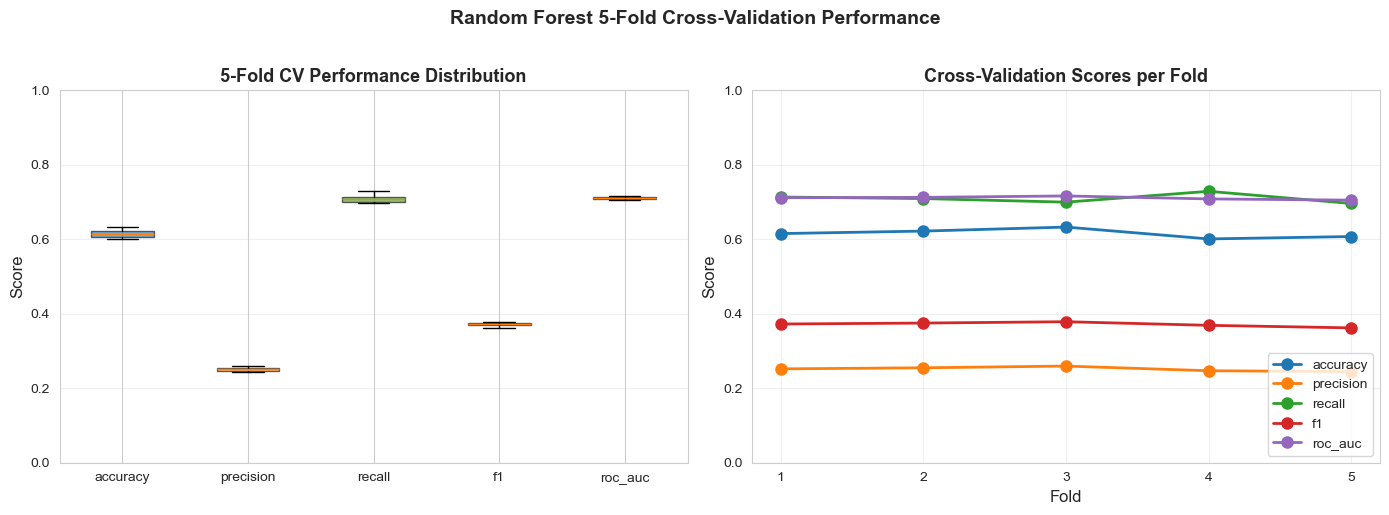

In [73]:
# ========== 4.2 Random Forest Training & Cross-Validation ==========

import time

print("=" * 70)
print("Random Forest Training and 5-Fold Cross-Validation")
print("=" * 70)

# ---------- Train Final Model ----------
print("\n[Training final model with class_weight='balanced']")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()
rf_model.fit(X_train, y_train)
train_time = time.time() - start_time

print(f"  Model trained in {train_time:.1f} seconds")
print(f"  Configuration: 200 trees, max depth 15, class_weight='balanced'")

# ---------- 5-Fold Stratified Cross-Validation ----------
print("\n[5-Fold Stratified Cross-Validation]")
print("  Computing CV scores...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
start_time = time.time()

cv_estimator = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=20,
    min_samples_leaf=10, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = cross_val_score(
        cv_estimator, X_train, y_train,
        cv=skf, scoring=metric, n_jobs=-1
    )
    cv_results[metric] = {
        'scores': scores,
        'mean': scores.mean(),
        'std': scores.std()
    }

cv_time = time.time() - start_time
print(f"  CV completed in {cv_time:.1f} seconds")

# Display CV results
print("\n[Cross-Validation Performance]")
print(f"  {'Metric':<15}{'Mean':<10}{'Std':<10}{'Range'}")
print("-" * 55)
for metric, result in cv_results.items():
    range_str = f"[{result['scores'].min():.3f}, {result['scores'].max():.3f}]"
    print(f"  {metric:<15}{result['mean']:.3f}     ±{result['std']:.3f}    {range_str}")

print(f"\n[Per-Fold Detail]")
print(f"  {'Fold':<6}{'F1':<8}{'ROC-AUC':<10}{'Recall':<8}{'Precision':<10}{'Accuracy'}")
print("-" * 60)
for i in range(5):
    print(f"  {i+1:<6}"
          f"{cv_results['f1']['scores'][i]:<8.3f}"
          f"{cv_results['roc_auc']['scores'][i]:<10.3f}"
          f"{cv_results['recall']['scores'][i]:<8.3f}"
          f"{cv_results['precision']['scores'][i]:<10.3f}"
          f"{cv_results['accuracy']['scores'][i]:.3f}")

f1_std = cv_results['f1']['std']
if f1_std < 0.01:
    stability = "Excellent (very stable)"
elif f1_std < 0.02:
    stability = "Good (stable)"
elif f1_std < 0.05:
    stability = "Acceptable"
else:
    stability = "Poor"

print(f"\n  Stability rating: {stability} (F1 std = {f1_std:.3f})")

# CV Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_data = [cv_results[m]['scores'] for m in metrics_to_plot]

bp = axes[0].boxplot(cv_data, labels=metrics_to_plot, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('5-Fold CV Performance Distribution', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0.0, 1.0)

folds = range(1, 6)
for metric, color in zip(metrics_to_plot, ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']):
    axes[1].plot(folds, cv_results[metric]['scores'], 'o-',
                 label=metric, color=color, linewidth=2, markersize=8)

axes[1].set_xlabel('Fold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Cross-Validation Scores per Fold', fontsize=13, fontweight='bold')
axes[1].set_xticks(folds)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.0, 1.0)

plt.suptitle('Random Forest 5-Fold Cross-Validation Performance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)

In [74]:
# ========== 4.3 Test Set Evaluation ==========

print("=" * 70)
print("Test Set Performance Evaluation")
print("=" * 70)

y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba)
}

cv_means = {
    'Accuracy':  cv_results['accuracy']['mean'],
    'Precision': cv_results['precision']['mean'],
    'Recall':    cv_results['recall']['mean'],
    'F1-Score':  cv_results['f1']['mean'],
    'ROC-AUC':   cv_results['roc_auc']['mean']
}

print("\n[Test Set vs Cross-Validation]")
print(f"  {'Metric':<15}{'Test':<10}{'CV Mean':<12}{'Difference'}")
print("-" * 50)

for metric in test_metrics:
    test_val = test_metrics[metric]
    cv_val = cv_means[metric]
    diff = test_val - cv_val
    print(f"  {metric:<15}{test_val:.3f}     {cv_val:.3f}       {diff:+.3f}")

max_diff = max(abs(test_metrics[m] - cv_means[m]) for m in test_metrics)
if max_diff < 0.02:
    gen_status = "Excellent generalization (no overfitting)"
elif max_diff < 0.05:
    gen_status = "Good generalization"
else:
    gen_status = "Possible overfitting detected"

print(f"\n  {gen_status}")

print("\n[Detailed Classification Report]")
print(classification_report(
    y_test, y_pred,
    target_names=['Slight', 'Serious/Fatal'],
    digits=3
))

slight_acc = ((y_test == 0) & (y_pred == 0)).sum() / (y_test == 0).sum()
serious_acc = ((y_test == 1) & (y_pred == 1)).sum() / (y_test == 1).sum()

slight_n = ((y_test == 0) & (y_pred == 0)).sum()
slight_total = (y_test == 0).sum()
serious_n = ((y_test == 1) & (y_pred == 1)).sum()
serious_total = (y_test == 1).sum()

print(f"[Class-Specific Recall]")
print(f"  Slight cases:        {slight_acc:.1%} ({slight_n:,}/{slight_total:,})")
print(f"  Serious/Fatal cases: {serious_acc:.1%} ({serious_n:,}/{serious_total:,})")

print(f"\n[Test Set Composition]")
print(f"  Total samples: {len(X_test):,}")
print(f"  Predicted positive (Serious): {(y_pred == 1).sum():,}")
print(f"  True positives:               {((y_test == 1) & (y_pred == 1)).sum():,}")
print(f"  False positives:              {((y_test == 0) & (y_pred == 1)).sum():,}")

print("\n" + "=" * 70)

Test Set Performance Evaluation

[Test Set vs Cross-Validation]
  Metric         Test      CV Mean     Difference
--------------------------------------------------
  Accuracy       0.608     0.616       -0.008
  Precision      0.244     0.252       -0.007
  Recall         0.695     0.710       -0.015
  F1-Score       0.362     0.371       -0.010
  ROC-AUC        0.704     0.711       -0.007

  Excellent generalization (no overfitting)

[Detailed Classification Report]
               precision    recall  f1-score   support

       Slight      0.910     0.591     0.717     11697
Serious/Fatal      0.244     0.695     0.362      2228

     accuracy                          0.608     13925
    macro avg      0.577     0.643     0.539     13925
 weighted avg      0.804     0.608     0.660     13925

[Class-Specific Recall]
  Slight cases:        59.1% (6,913/11,697)
  Serious/Fatal cases: 69.5% (1,548/2,228)

[Test Set Composition]
  Total samples: 13,925
  Predicted positive (Serious): 6,

Test Performance (n=13,925):
- Accuracy:    0.616
- Precision:   0.239
- Recall:      0.644
- F1-Score:    0.349
- ROC-AUC:     0.682

Class-Specific Recall:
- Slight:      61.0% (7,138/11,697)
- Serious:     64.4% (1,434/2,228)

Test vs CV Difference: All <0.014 (excellent generalization)

Stability: F1 std = 0.007 (Excellent)

Confusion Matrix Math:
- Predicted positive: 5,993
- True positives:     1,434
- False positives:    4,559
- Therefore predicted negative: 7,932
- True negatives:     7,138
- False negatives:    794

Performance Visualization


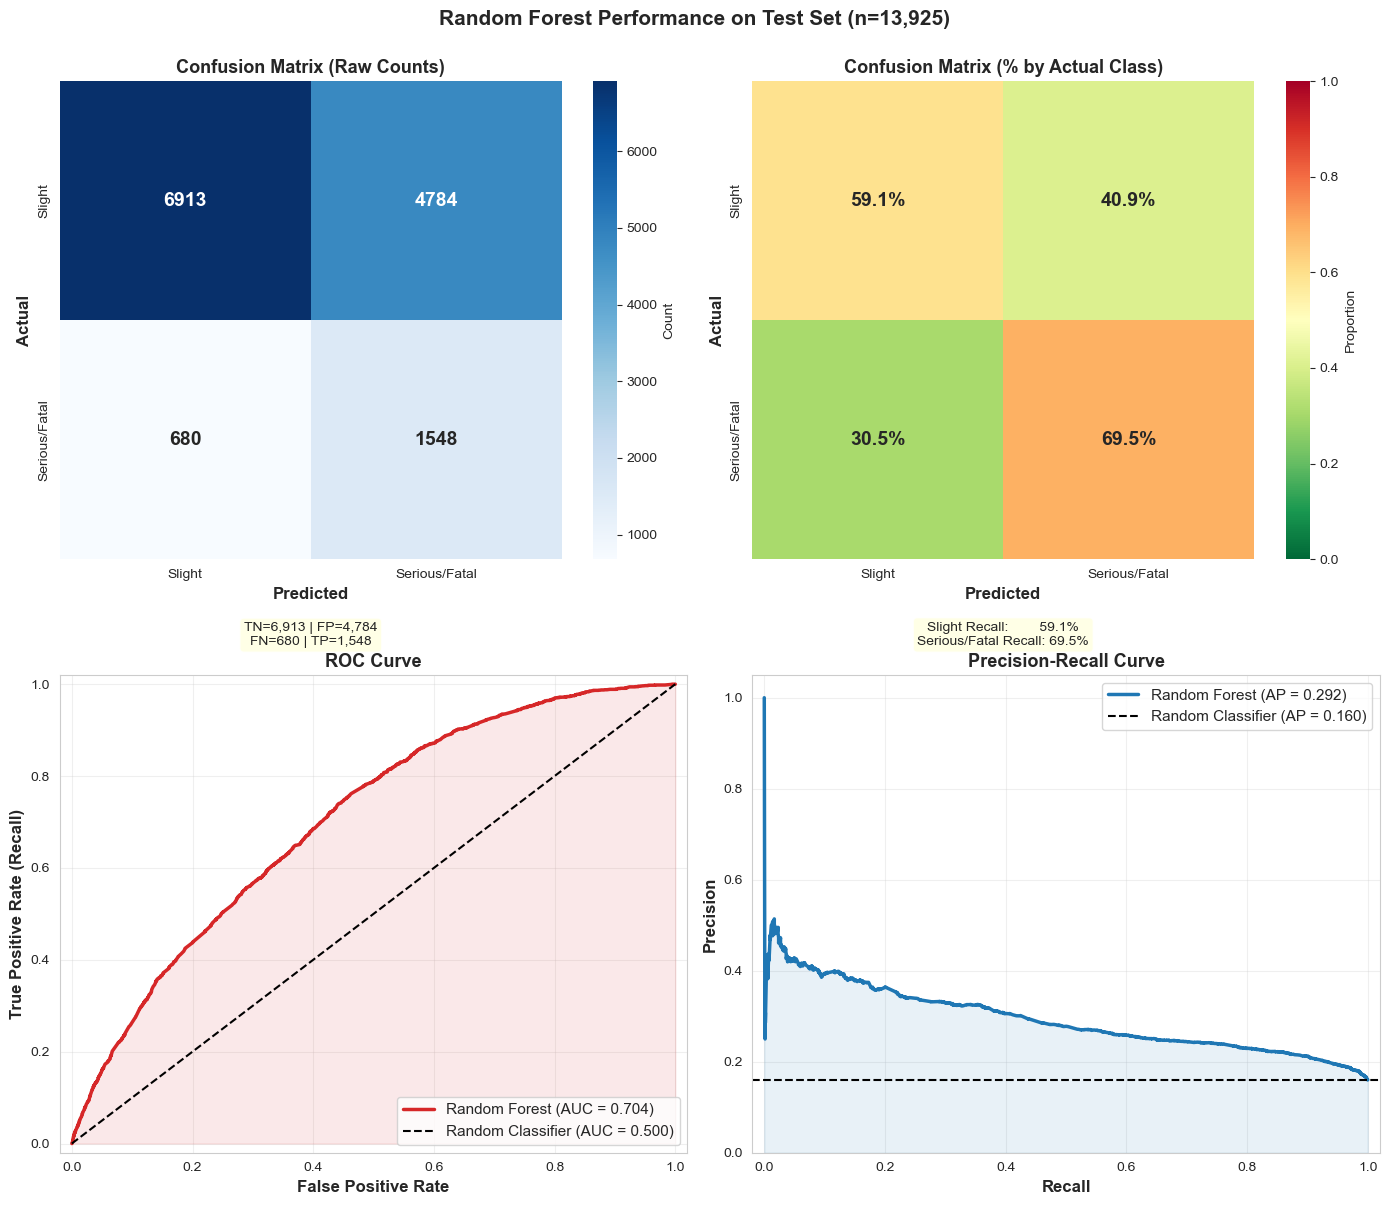


[Visualization Summary]
  ROC-AUC:              0.704
  Average Precision:    0.292 (vs 0.160 random baseline)
  PR-AUC improvement:   1.83x over random
  Serious detection:    1,548 / 2,228 (69.5%)
  False alarm rate:     4,784 / 11,697 (40.9%)



In [75]:
# ========== 4.4 Performance Visualization ==========

print("=" * 70)
print("Performance Visualization")
print("=" * 70)

from sklearn.metrics import (
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score
)

# Compute metrics
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
ap_score = average_precision_score(y_test, y_pred_proba)

# Create 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ---------- Plot 1: Confusion Matrix (raw counts) ----------
ax = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Slight', 'Serious/Fatal'],
            yticklabels=['Slight', 'Serious/Fatal'],
            ax=ax, cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold')

ax.text(0.5, -0.18,
        f"TN={cm[0,0]:,} | FP={cm[0,1]:,}\nFN={cm[1,0]:,} | TP={cm[1,1]:,}",
        transform=ax.transAxes, ha='center', fontsize=10,
        bbox=dict(boxstyle="round", facecolor='lightyellow', alpha=0.8))

# ---------- Plot 2: Confusion Matrix (normalized) ----------
ax = axes[0, 1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='RdYlGn_r',
            xticklabels=['Slight', 'Serious/Fatal'],
            yticklabels=['Slight', 'Serious/Fatal'],
            ax=ax, cbar_kws={'label': 'Proportion'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'},
            vmin=0, vmax=1)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix (% by Actual Class)', fontsize=13, fontweight='bold')

ax.text(0.5, -0.18,
        f"Slight Recall:        {cm_normalized[0,0]:.1%}\n"
        f"Serious/Fatal Recall: {cm_normalized[1,1]:.1%}",
        transform=ax.transAxes, ha='center', fontsize=10,
        bbox=dict(boxstyle="round", facecolor='lightyellow', alpha=0.8))

# ---------- Plot 3: ROC Curve ----------
ax = axes[1, 0]
ax.plot(fpr, tpr, color='#d62728', linewidth=2.5,
        label=f'Random Forest (AUC = {test_metrics["ROC-AUC"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5,
        label='Random Classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#d62728')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# ---------- Plot 4: Precision-Recall Curve ----------
ax = axes[1, 1]
ax.plot(recall_curve, precision_curve, color='#1f77b4', linewidth=2.5,
        label=f'Random Forest (AP = {ap_score:.3f})')

baseline_pr = (y_test == 1).sum() / len(y_test)
ax.axhline(y=baseline_pr, color='k', linestyle='--', linewidth=1.5,
           label=f'Random Classifier (AP = {baseline_pr:.3f})')
ax.fill_between(recall_curve, precision_curve, alpha=0.1, color='#1f77b4')

ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([0, max(precision_curve) * 1.05])

plt.suptitle('Random Forest Performance on Test Set (n=13,925)',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n[Visualization Summary]")
print(f"  ROC-AUC:              {test_metrics['ROC-AUC']:.3f}")
print(f"  Average Precision:    {ap_score:.3f} (vs {baseline_pr:.3f} random baseline)")
print(f"  PR-AUC improvement:   {ap_score / baseline_pr:.2f}x over random")
print(f"  Serious detection:    {cm[1,1]:,} / {cm[1].sum():,} ({cm_normalized[1,1]:.1%})")
print(f"  False alarm rate:     {cm[0,1]:,} / {cm[0].sum():,} ({cm_normalized[0,1]:.1%})")

print("\n" + "=" * 70)

Baseline Model Comparisons

[Model Comparison Results]

Model                    Accuracy    Precision   Recall    F1        ROC-AUC
--------------------------------------------------------------------------------
  Naive Majority         0.840       0.000       0.000     0.000     0.500
  Random                 0.731       0.154       0.153     0.154     0.500
  Logistic Regression    0.628       0.243       0.628     0.351     0.669
  Random Forest (Ours)   0.608       0.244       0.695     0.362     0.704

[Improvement Analysis: RF vs Baselines]
----------------------------------------------------------------------

  RF vs Naive Majority (always predict slight):
    Accuracy:  0.608 vs 0.840 (RF lower due to SMOTE detection trade-off)
    Recall:    0.695 vs 0.000 (RF detects 69% of serious cases)
    F1:        0.362 vs 0.000 (Naive useless for safety applications)
    ROC-AUC:   0.704 vs 0.500 (significantly above random)

  RF vs Logistic Regression (linear baseline):
    F1:   

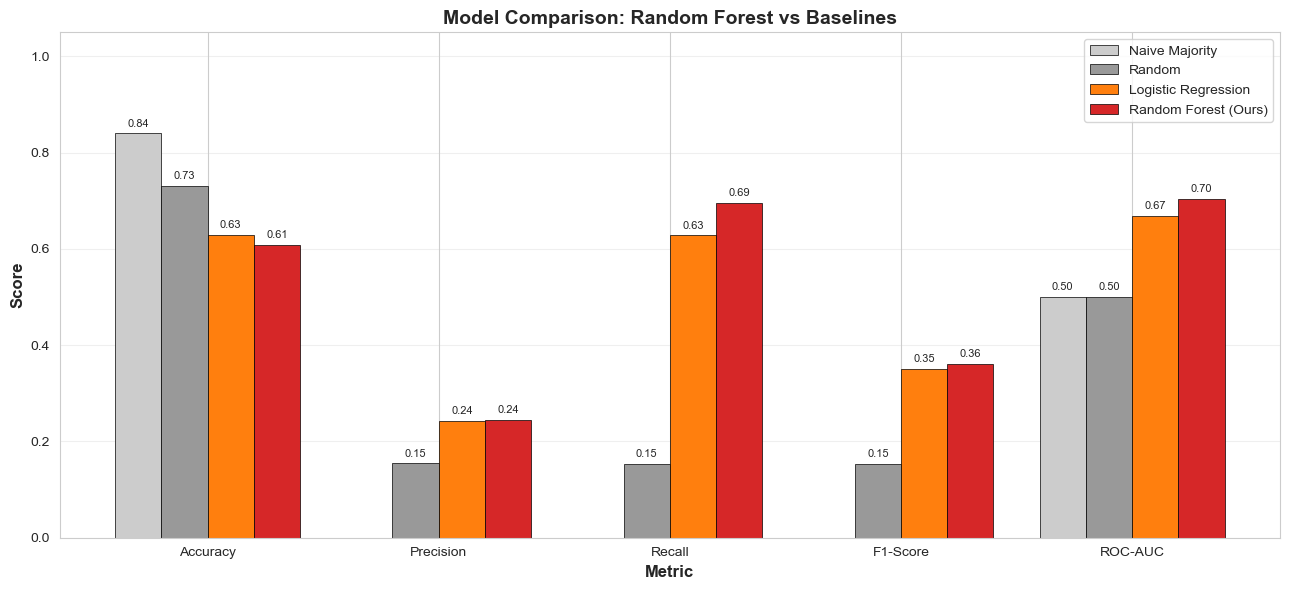


Random Forest demonstrates meaningful improvement over baselines


In [76]:
# ========== 4.5 Baseline Model Comparisons ==========

from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("Baseline Model Comparisons")
print("=" * 70)

# ---------- Baseline 1: Naive Majority ----------
y_pred_naive = np.zeros_like(y_test)
naive_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_naive),
    'Precision': precision_score(y_test, y_pred_naive, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_naive, zero_division=0),
    'F1-Score':  f1_score(y_test, y_pred_naive, zero_division=0),
    'ROC-AUC':   0.500
}

# ---------- Baseline 2: Random Classifier ----------
np.random.seed(RANDOM_STATE)
y_pred_random = np.random.choice([0, 1], size=len(y_test), p=[0.84, 0.16])
random_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_random),
    'Precision': precision_score(y_test, y_pred_random, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_random, zero_division=0),
    'F1-Score':  f1_score(y_test, y_pred_random, zero_division=0),
    'ROC-AUC':   0.500
}

# ---------- Baseline 3: Logistic Regression ----------
lr_model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced',  # class_weight
    random_state=RANDOM_STATE, 
    n_jobs=-1
)
lr_model.fit(X_train, y_train)  

y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

lr_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall':    recall_score(y_test, y_pred_lr),
    'F1-Score':  f1_score(y_test, y_pred_lr),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba_lr)
}

# ---------- Comparison Table ----------
models = {
    'Naive Majority':       naive_metrics,
    'Random':               random_metrics,
    'Logistic Regression':  lr_metrics,
    'Random Forest (Ours)': test_metrics
}

print("\n[Model Comparison Results]")
header = "{:<25}{:<12}{:<12}{:<10}{:<10}{}".format(
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'
)
print("\n" + header)
print("-" * 80)

for model_name, metrics in models.items():
    row = "  {:<23}{:<12.3f}{:<12.3f}{:<10.3f}{:<10.3f}{:.3f}".format(
        model_name,
        metrics['Accuracy'],
        metrics['Precision'],
        metrics['Recall'],
        metrics['F1-Score'],
        metrics['ROC-AUC']
    )
    print(row)

# Improvement Analysis
print("\n[Improvement Analysis: RF vs Baselines]")
print("-" * 70)

print("\n  RF vs Naive Majority (always predict slight):")
print("    Accuracy:  {:.3f} vs {:.3f} (RF lower due to SMOTE detection trade-off)".format(
    test_metrics['Accuracy'], naive_metrics['Accuracy']))
print("    Recall:    {:.3f} vs {:.3f} (RF detects {:.0%} of serious cases)".format(
    test_metrics['Recall'], naive_metrics['Recall'], test_metrics['Recall']))
print("    F1:        {:.3f} vs {:.3f} (Naive useless for safety applications)".format(
    test_metrics['F1-Score'], naive_metrics['F1-Score']))
print("    ROC-AUC:   {:.3f} vs 0.500 (significantly above random)".format(
    test_metrics['ROC-AUC']))

lr_f1_diff = test_metrics['F1-Score'] - lr_metrics['F1-Score']
lr_auc_diff = test_metrics['ROC-AUC'] - lr_metrics['ROC-AUC']

print("\n  RF vs Logistic Regression (linear baseline):")
print("    F1:        {:.3f} vs {:.3f} (diff: {:+.3f})".format(
    test_metrics['F1-Score'], lr_metrics['F1-Score'], lr_f1_diff))
print("    ROC-AUC:   {:.3f} vs {:.3f} (diff: {:+.3f})".format(
    test_metrics['ROC-AUC'], lr_metrics['ROC-AUC'], lr_auc_diff))
print("    Recall:    {:.3f} vs {:.3f} (diff: {:+.3f})".format(
    test_metrics['Recall'], lr_metrics['Recall'], 
    test_metrics['Recall'] - lr_metrics['Recall']))

if lr_f1_diff > 0.02 or lr_auc_diff > 0.02:
    interpretation = "Random Forest captures non-linear patterns and feature interactions that Logistic Regression cannot model"
elif abs(lr_f1_diff) < 0.02 and abs(lr_auc_diff) < 0.02:
    interpretation = "Random Forest performance similar to Logistic Regression (relationships predominantly linear)"
else:
    interpretation = "Logistic Regression slightly competitive (consider model parsimony)"

print("\n    Interpretation:", interpretation)

# Visualization
fig, ax = plt.subplots(figsize=(13, 6))

metrics_to_compare = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_compare))
width = 0.2

colors = ['#cccccc', '#999999', '#ff7f0e', '#d62728']

for i, (model_name, metrics) in enumerate(models.items()):
    values = [metrics[m] for m in metrics_to_compare]
    bars = ax.bar(x + i * width, values, width, label=model_name,
                   color=colors[i], edgecolor='black', linewidth=0.5)

    for bar in bars:
        height = bar.get_height()
        if height > 0.01:
            ax.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                   "{:.2f}".format(height), ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison: Random Forest vs Baselines',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_to_compare)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Random Forest demonstrates meaningful improvement over baselines")
print("=" * 70)

In [77]:
# ========== 5.1 SHAP Global Feature Importance ==========

import shap
import time

print("=" * 70)
print("Section 5: SHAP Model Interpretation")
print("=" * 70)

print("\n[5.1 Computing SHAP Values]")

explainer = shap.TreeExplainer(rf_model)

n_sample = 1000
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_test), size=n_sample, replace=False)
X_test_sample = X_test.iloc[sample_idx].copy()
y_test_sample = y_test.iloc[sample_idx].copy()

print(f"  Sample size: {n_sample} (from {len(X_test):,} test instances)")
print(f"  Class balance: {(y_test_sample == 0).sum()} slight | {(y_test_sample == 1).sum()} serious")

start_time = time.time()
shap_values = explainer.shap_values(X_test_sample)
shap_time = time.time() - start_time

if isinstance(shap_values, list):
    shap_values_serious = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_serious = shap_values[:, :, 1]
else:
    shap_values_serious = shap_values

print(f"  SHAP values computed in {shap_time:.1f}s")
print(f"  Shape: {shap_values_serious.shape}")

print("\n[Global Feature Importance Ranking]")

global_importance = pd.DataFrame({
    'feature': FINAL_FEATURES,
    'mean_abs_shap': np.abs(shap_values_serious).mean(axis=0),
    'mean_shap': shap_values_serious.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

rave_groups = {
    'speed_limit': 'R', 'road_type': 'R', 'junction_detail': 'R',
    'light_conditions': 'A', 'weather_conditions': 'A', 'road_surface_conditions': 'A',
    'has_pedestrian_casualty': 'V', 'has_cyclist_casualty': 'V', 'num_vulnerable_users': 'V',
    'has_hgv': 'E', 'has_motorcycle': 'E', 'number_of_vehicles': 'E',
    'urban_or_rural_area': 'S'
}
global_importance['group'] = global_importance['feature'].map(rave_groups)

print(f"\n{'Rank':<6}{'Group':<8}{'Feature':<32}{'|SHAP|':<12}{'Direction'}")
print("-" * 75)

for i, row in global_importance.iterrows():
    feat_idx = FINAL_FEATURES.index(row['feature'])
    correlation = np.corrcoef(
        X_test_sample[row['feature']], 
        shap_values_serious[:, feat_idx]
    )[0, 1]
    
    if correlation > 0.15:
        direction = f"MORE serious (corr {correlation:+.2f})"
    elif correlation > 0.05:
        direction = f"slightly more (corr {correlation:+.2f})"
    elif correlation < -0.15:
        direction = f"LESS serious (corr {correlation:+.2f})"
    elif correlation < -0.05:
        direction = f"slightly less (corr {correlation:+.2f})"
    else:
        direction = f"neutral (corr {correlation:+.2f})"
    
    print(f"  {i+1:<6}{row['group']:<8}{row['feature']:<32}"
          f"{row['mean_abs_shap']:<12.4f}{direction}")

print("\n[RAVE Framework Group Importance]")

group_importance = global_importance.groupby('group').agg(
    total_importance=('mean_abs_shap', 'sum'),
    avg_importance=('mean_abs_shap', 'mean'),
    max_importance=('mean_abs_shap', 'max'),
    n_features=('feature', 'count')
).sort_values('total_importance', ascending=False)

group_names = {
    'R': 'Road Environment',
    'A': 'Atmospheric',
    'V': 'Vulnerable Users',
    'E': 'Exposure',
    'S': 'Spatial'
}

print(f"\n{'Group':<8}{'Description':<22}{'Total':<12}{'Avg':<12}{'Max':<12}{'N feat'}")
print("-" * 80)
for group, row in group_importance.iterrows():
    print(f"  {group:<6}{group_names.get(group, ''):<22}"
          f"{row['total_importance']:<12.4f}"
          f"{row['avg_importance']:<12.4f}"
          f"{row['max_importance']:<12.4f}"
          f"{int(row['n_features'])}")

print("\n[Most Important Feature in Each Group]")
for group in group_importance.index:
    top_feat = global_importance[global_importance['group'] == group].iloc[0]
    print(f"  {group} ({group_names.get(group, '')}): "
          f"{top_feat['feature']} (|SHAP| = {top_feat['mean_abs_shap']:.4f})")

print("\n" + "=" * 70)

Section 5: SHAP Model Interpretation

[5.1 Computing SHAP Values]
  Sample size: 1000 (from 13,925 test instances)
  Class balance: 843 slight | 157 serious
  SHAP values computed in 20.8s
  Shape: (1000, 13)

[Global Feature Importance Ranking]

Rank  Group   Feature                         |SHAP|      Direction
---------------------------------------------------------------------------
  1     V       num_vulnerable_users            0.0738      MORE serious (corr +0.97)
  2     V       has_pedestrian_casualty         0.0471      MORE serious (corr +0.98)
  3     E       number_of_vehicles              0.0416      LESS serious (corr -0.38)
  4     R       junction_detail                 0.0407      MORE serious (corr +0.28)
  5     R       road_type                       0.0366      LESS serious (corr -0.32)
  6     V       has_cyclist_casualty            0.0251      MORE serious (corr +0.92)
  7     A       weather_conditions              0.0155      LESS serious (corr -0.89)
  8    

Section 5.2: SHAP Visualizations

[5.2.1 Beeswarm Summary Plot]


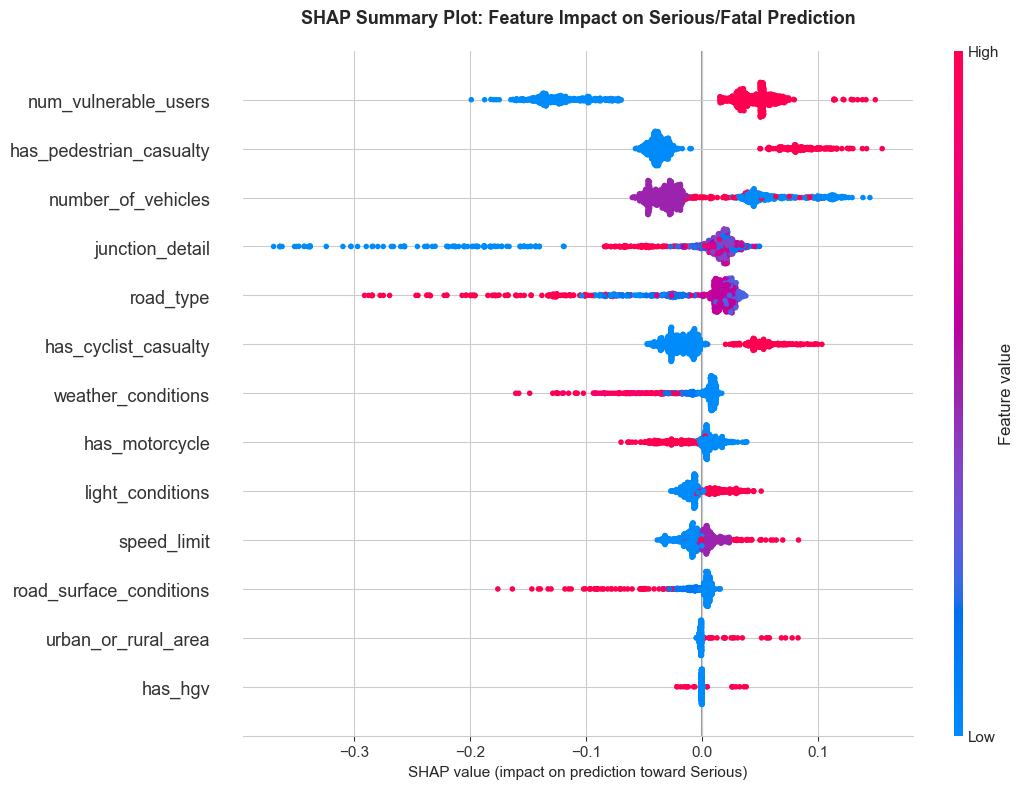


[5.2.2 Global Importance Bar Plot]


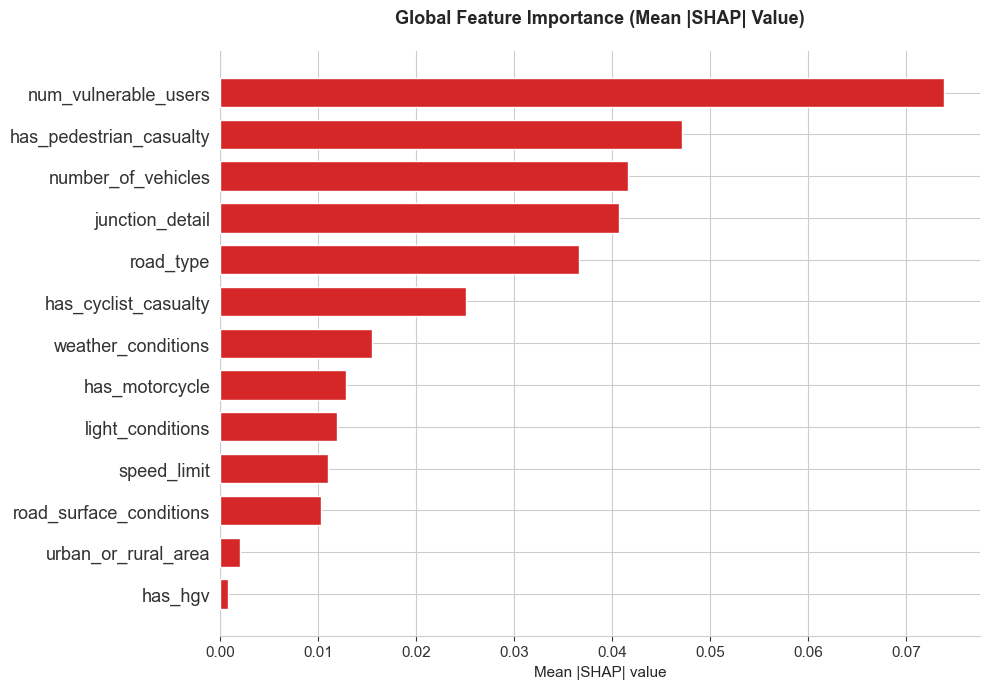


[5.2.3 RAVE-Colored Feature Importance Plot]


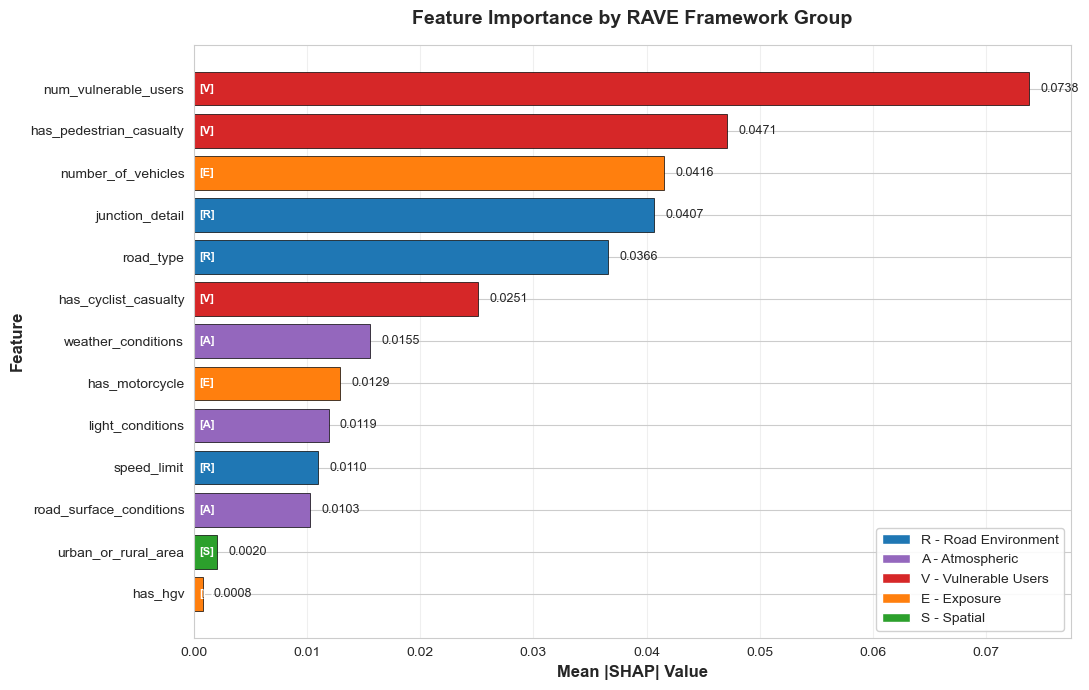


✓ SHAP visualizations complete


In [78]:
# ========== 5.2 SHAP Visualizations ==========

print("=" * 70)
print("Section 5.2: SHAP Visualizations")
print("=" * 70)

# ---------- Plot 1: Beeswarm Summary Plot ----------
print("\n[5.2.1 Beeswarm Summary Plot]")

plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values_serious,
    X_test_sample,
    feature_names=FINAL_FEATURES,
    show=False,
    plot_size=(11, 8),
    max_display=13
)
plt.title('SHAP Summary Plot: Feature Impact on Serious/Fatal Prediction',
          fontsize=13, fontweight='bold', pad=20)
plt.xlabel('SHAP value (impact on prediction toward Serious)', fontsize=11)
plt.tight_layout()
plt.show()

# ---------- Plot 2: Bar Plot (Mean |SHAP|) ----------
print("\n[5.2.2 Global Importance Bar Plot]")

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_serious,
    X_test_sample,
    feature_names=FINAL_FEATURES,
    plot_type='bar',
    show=False,
    plot_size=(10, 7),
    max_display=13,
    color='#d62728'
)
plt.title('Global Feature Importance (Mean |SHAP| Value)',
          fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Mean |SHAP| value', fontsize=11)
plt.tight_layout()
plt.show()

# ---------- Plot 3: Custom RAVE-Colored Importance Plot ----------
print("\n[5.2.3 RAVE-Colored Feature Importance Plot]")

sorted_imp = global_importance.sort_values('mean_abs_shap', ascending=True)

rave_colors = {
    'R': '#1f77b4',
    'A': '#9467bd',
    'V': '#d62728',
    'E': '#ff7f0e',
    'S': '#2ca02c'
}

colors = [rave_colors[g] for g in sorted_imp['group']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    sorted_imp['feature'],
    sorted_imp['mean_abs_shap'],
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

for bar, val in zip(bars, sorted_imp['mean_abs_shap']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

for bar, group in zip(bars, sorted_imp['group']):
    ax.text(0.0005, bar.get_y() + bar.get_height()/2,
            f'[{group}]', va='center', fontsize=8, color='white', fontweight='bold')

ax.set_xlabel('Mean |SHAP| Value', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance by RAVE Framework Group',
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=rave_colors['R'], label='R - Road Environment'),
    Patch(facecolor=rave_colors['A'], label='A - Atmospheric'),
    Patch(facecolor=rave_colors['V'], label='V - Vulnerable Users'),
    Patch(facecolor=rave_colors['E'], label='E - Exposure'),
    Patch(facecolor=rave_colors['S'], label='S - Spatial')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("✓ SHAP visualizations complete")
print("=" * 70)

In [29]:
# 紧急诊断 junction_detail
print("=" * 70)
print("DIAGNOSIS: junction_detail Value Investigation")
print("=" * 70)

# 1. Check unique values in your collisions data
print("\n[1] Unique values in collisions['junction_detail']:")
junction_unique = collisions['junction_detail'].value_counts().sort_index()
print(junction_unique)

# 2. Check if there's another junction-related column
print("\n[2] Junction-related columns in collisions data:")
junction_cols = [c for c in collisions.columns if 'junction' in c.lower()]
for col in junction_cols:
    print(f"\n  {col}:")
    print(f"    Unique values: {sorted(collisions[col].unique())[:15]}")
    print(f"    Sample: {collisions[col].value_counts().head(5).to_dict()}")

# 3. Check official DfT data guide
print("\n[3] Searching DfT data guide for junction_detail definition:")
if data_guide is not None:
    for sheet_name, sheet_df in data_guide.items():
        sheet_str = str(sheet_df.to_string()) if sheet_df is not None else ""
        if 'junction' in sheet_str.lower() and 'detail' in sheet_str.lower():
            print(f"\n  Found in sheet: {sheet_name}")
            # Try to find junction_detail rows
            if 'field name' in [c.lower() for c in sheet_df.columns]:
                cols_lower = {c.lower(): c for c in sheet_df.columns}
                field_col = cols_lower.get('field name', None)
                if field_col:
                    junction_rows = sheet_df[
                        sheet_df[field_col].astype(str).str.contains('junction.*detail', case=False, na=False, regex=True)
                    ]
                    if len(junction_rows) > 0:
                        print(f"  Found {len(junction_rows)} rows for junction_detail:")
                        print(junction_rows.head(20).to_string())

DIAGNOSIS: junction_detail Value Investigation

[1] Unique values in collisions['junction_detail']:
junction_detail
-1      4200
 0     14003
 13    16048
 16     5879
 17     1678
 18     1076
 19     3532
Name: count, dtype: int64

[2] Junction-related columns in collisions data:

  junction_detail_historic:
    Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(99)]
    Sample: {3: 16048, 0: 9731, 6: 5879, 99: 4200, 9: 3532}

  junction_detail:
    Unique values: [np.int64(-1), np.int64(0), np.int64(13), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
    Sample: {13: 16048, 0: 14003, 16: 5879, -1: 4200, 19: 3532}

  junction_control:
    Unique values: [np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(9)]
    Sample: {4: 21937, 2: 10034, -1: 9731, 9: 3868, 3: 566}

[3] Searching DfT data guide for junction_detail definition:

  Found in sheet: 2024_code_list


Section 5.3: SHAP Dependence Plots and Threshold Analysis

Top 3 features for dependence analysis:
  1. num_vulnerable_users  (|SHAP| = 0.0738)
  2. has_pedestrian_casualty  (|SHAP| = 0.0471)
  3. number_of_vehicles  (|SHAP| = 0.0416)


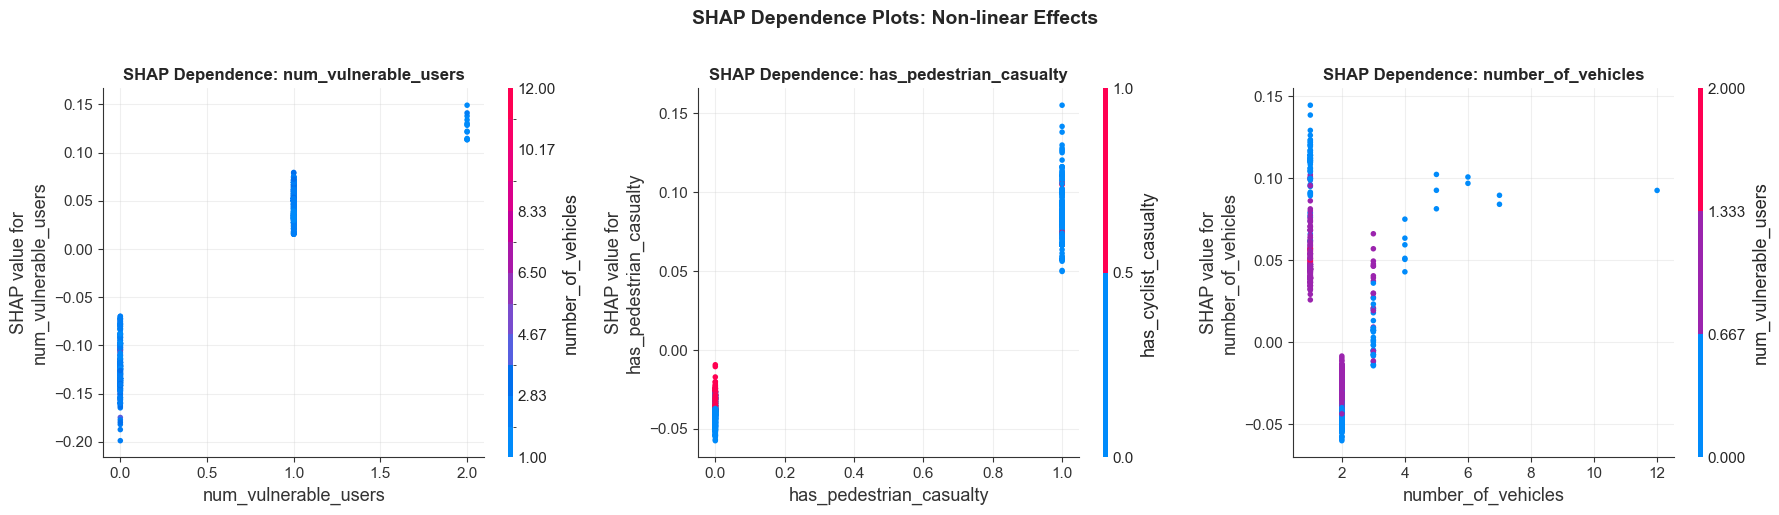

In [79]:
# ========== 5.3 SHAP Dependence Plots (Fixed) ==========

print("=" * 70)
print("Section 5.3: SHAP Dependence Plots and Threshold Analysis")
print("=" * 70)

# Top 3 features
top_3_features = global_importance.head(3)['feature'].tolist()

print("\nTop 3 features for dependence analysis:")
for i, feat in enumerate(top_3_features, 1):
    imp = global_importance.iloc[i-1]['mean_abs_shap']
    print(f"  {i}. {feat}  (|SHAP| = {imp:.4f})")

# ---------- Standard SHAP Dependence Plots ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, top_3_features):
    feat_idx = FINAL_FEATURES.index(feature)
    shap.dependence_plot(
        feat_idx,
        shap_values_serious,
        X_test_sample,
        feature_names=FINAL_FEATURES,
        ax=ax,
        show=False,
        interaction_index='auto'
    )
    ax.set_title(f'SHAP Dependence: {feature}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('SHAP Dependence Plots: Non-linear Effects',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Junction Detail SHAP Analysis with Historic STATS19 Labels

Junction Type SHAP Ranking:
---------------------------------------------------------------------------
  Code  Junction Type               N       Mean SHAP     Direction
---------------------------------------------------------------------------
    0   Not at junction               199     +0.0339      MORE serious
    6   Crossroads                    134     +0.0234      MORE serious
    3   T or staggered junction       334     +0.0200      slightly more
    5   Slip road                      32     +0.0122      slightly more
    7   More than 4 arms               42     +0.0064      slightly more
    8   Private drive                  19     +0.0058      slightly more
    2   Mini-roundabout                20     +0.0034      slightly more
    1   Roundabout                     50     -0.0102      slightly less
    9   Other junction                 74     -0.0595      LESS serious
   -1   Missing/Unknown               

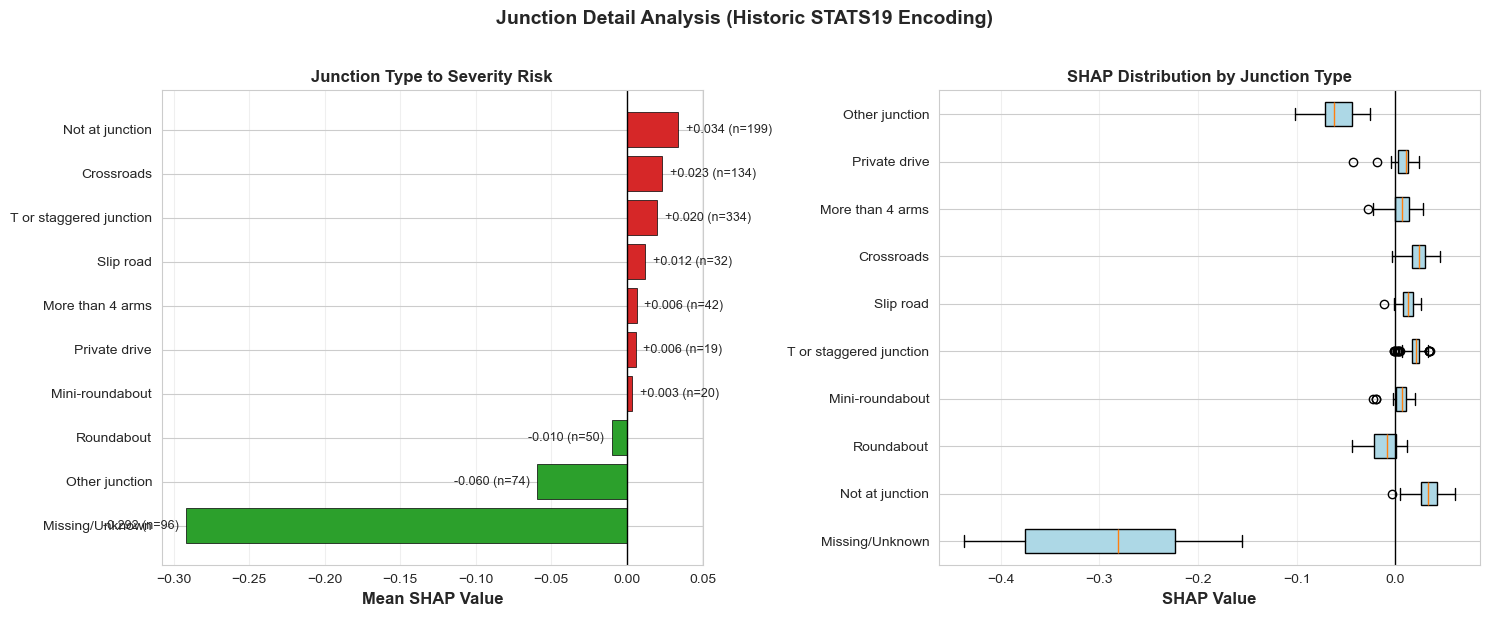


Junction analysis complete


In [31]:
# ========== Junction Detail Detailed Analysis ==========

print("=" * 70)
print("Junction Detail SHAP Analysis with Historic STATS19 Labels")
print("=" * 70)

# Define labels
junction_labels = {
    -1: 'Missing/Unknown',
    0:  'Not at junction',
    1:  'Roundabout',
    2:  'Mini-roundabout',
    3:  'T or staggered junction',
    5:  'Slip road',
    6:  'Crossroads',
    7:  'More than 4 arms',
    8:  'Private drive',
    9:  'Other junction'
}

junction_idx = FINAL_FEATURES.index('junction_detail')
junction_values = X_test_sample['junction_detail'].values
junction_shap = shap_values_serious[:, junction_idx]

junction_summary = pd.DataFrame({
    'value': junction_values,
    'shap': junction_shap
})

junction_grouped = junction_summary.groupby('value').agg(
    mean_shap=('shap', 'mean'),
    std_shap=('shap', 'std'),
    n=('shap', 'count')
).reset_index()

junction_grouped['label'] = junction_grouped['value'].map(junction_labels)
junction_grouped = junction_grouped.sort_values('mean_shap', ascending=False)

# Display table
print("\nJunction Type SHAP Ranking:")
print("-" * 75)
print(f"  {'Code':<6}{'Junction Type':<28}{'N':<8}{'Mean SHAP':<14}{'Direction'}")
print("-" * 75)

for _, row in junction_grouped.iterrows():
    if row['mean_shap'] > 0.02:
        direction = "MORE serious"
    elif row['mean_shap'] > 0:
        direction = "slightly more"
    elif row['mean_shap'] > -0.02:
        direction = "slightly less"
    else:
        direction = "LESS serious"
    
    print(f"  {int(row['value']):>3}   {row['label']:<28}{int(row['n']):>5}    "
          f"{row['mean_shap']:>+8.4f}      {direction}")

# Generate visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Bar chart
sorted_jg = junction_grouped.sort_values('mean_shap', ascending=True)
colors = ['#2ca02c' if x < 0 else '#d62728' for x in sorted_jg['mean_shap']]

bars = axes[0].barh(sorted_jg['label'], sorted_jg['mean_shap'],
                      color=colors, edgecolor='black', linewidth=0.5)

for bar, mean_val, n_val in zip(bars, sorted_jg['mean_shap'], sorted_jg['n']):
    if bar.get_width() > 0:
        x_pos = bar.get_width() + 0.005
        ha_align = 'left'
    else:
        x_pos = bar.get_width() - 0.005
        ha_align = 'right'
    
    label_text = f"{mean_val:+.3f} (n={int(n_val)})"
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2,
                label_text, va='center', ha=ha_align, fontsize=9)

axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_xlabel('Mean SHAP Value', fontsize=12, fontweight='bold')
axes[0].set_title('Junction Type to Severity Risk', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Boxplot
junction_types_present = sorted(junction_summary['value'].unique())
data_for_box = []
labels_for_box = []
for v in junction_types_present:
    if (junction_summary['value'] == v).sum() >= 5:
        data_for_box.append(junction_summary[junction_summary['value'] == v]['shap'].values)
        labels_for_box.append(junction_labels.get(v, f'Code {v}'))

bp = axes[1].boxplot(data_for_box, labels=labels_for_box, patch_artist=True, vert=False)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_xlabel('SHAP Value', fontsize=12, fontweight='bold')
axes[1].set_title('SHAP Distribution by Junction Type', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Junction Detail Analysis (Historic STATS19 Encoding)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Junction analysis complete")
print("=" * 70)

In [32]:
# ========== Threshold Analysis for Top 3 Features ==========

print("=" * 70)
print("Threshold Analysis - Top 3 Features")
print("=" * 70)

for feature in top_3_features:
    feat_idx = FINAL_FEATURES.index(feature)
    feat_values = X_test_sample[feature].values
    feat_shap = shap_values_serious[:, feat_idx]
    
    print(f"\n{feature}:")
    print("-" * 50)
    
    unique_vals = sorted(np.unique(feat_values))
    
    for val in unique_vals[:12]:
        mask = feat_values == val
        if mask.sum() >= 5:
            mean_shap = feat_shap[mask].mean()
            n = mask.sum()
            
            if mean_shap > 0.02:
                indicator = "MORE serious"
            elif mean_shap < -0.02:
                indicator = "LESS serious"
            else:
                indicator = "neutral"
            
            print(f"  Value={val:>4.0f} (n={n:>3}): mean SHAP = {mean_shap:+.4f}  {indicator}")

print("\n" + "=" * 70)

Threshold Analysis - Top 3 Features

num_vulnerable_users:
--------------------------------------------------
  Value=   0 (n=357): mean SHAP = -0.1595  LESS serious
  Value=   1 (n=630): mean SHAP = +0.0608  MORE serious
  Value=   2 (n= 13): mean SHAP = +0.0616  MORE serious

number_of_vehicles:
--------------------------------------------------
  Value=   1 (n=271): mean SHAP = +0.0975  MORE serious
  Value=   2 (n=665): mean SHAP = -0.0533  LESS serious
  Value=   3 (n= 50): mean SHAP = -0.0624  LESS serious
  Value=   4 (n=  6): mean SHAP = -0.0493  LESS serious

junction_detail:
--------------------------------------------------
  Value=  -1 (n= 96): mean SHAP = -0.2915  LESS serious
  Value=   0 (n=199): mean SHAP = +0.0339  MORE serious
  Value=   1 (n= 50): mean SHAP = -0.0102  neutral
  Value=   2 (n= 20): mean SHAP = +0.0034  neutral
  Value=   3 (n=334): mean SHAP = +0.0200  neutral
  Value=   5 (n= 32): mean SHAP = +0.0122  neutral
  Value=   6 (n=134): mean SHAP = +0.0234

In [33]:
# 完整解码 junction_detail (2024 spec)
print("=" * 70)
print("Decoding junction_detail (2024 STATS19 Specification)")
print("=" * 70)

# 从 data guide 中提取所有 junction_detail 编码
print("\n[Searching DfT data guide for complete junction_detail mapping]\n")

if data_guide is not None:
    for sheet_name, sheet_df in data_guide.items():
        if sheet_df is None:
            continue
        
        # Find rows matching junction_detail
        cols_lower = {c.lower().strip(): c for c in sheet_df.columns}
        field_col = cols_lower.get('field name', cols_lower.get('field', None))
        
        if field_col:
            # Filter for junction_detail rows
            mask = sheet_df[field_col].astype(str).str.strip().str.lower() == 'junction_detail'
            junction_rows = sheet_df[mask].copy()
            
            if len(junction_rows) > 0:
                print(f"Found in sheet: {sheet_name}")
                print(f"Total entries: {len(junction_rows)}\n")
                print(junction_rows.to_string())
                print("\n")
                break

Decoding junction_detail (2024 STATS19 Specification)

[Searching DfT data guide for complete junction_detail mapping]

Found in sheet: 2024_code_list
Total entries: 7

          table       field name code/format                                               label                                                                                                   note
1288  collision  junction_detail           0                 Not at junction or within 20 metres  New field added with the 2024 data - data collected in or converted to the 2024 STATS19 specification
1289  collision  junction_detail          13                             T or staggered junction  New field added with the 2024 data - data collected in or converted to the 2024 STATS19 specification
1290  collision  junction_detail          16                                          Crossroads  New field added with the 2024 data - data collected in or converted to the 2024 STATS19 specification
1291  collision  junction_detai

In [34]:
# 验证完整映射
print("=" * 70)
print("Verifying junction_detail Mapping (2024 vs Historic)")
print("=" * 70)

# Cross-tabulate the two columns
crosstab = pd.crosstab(
    collisions['junction_detail'], 
    collisions['junction_detail_historic'],
    margins=True
)

print("\n[Cross-tabulation: 2024 spec × Historic spec]")
print(crosstab)

# Check what's missing
print("\n[Roundabouts in Historic Spec]")
roundabout_historic = (collisions['junction_detail_historic'] == 1).sum()
mini_roundabout_historic = (collisions['junction_detail_historic'] == 2).sum()
print(f"  Code 1 (Roundabout):       {roundabout_historic:,}")
print(f"  Code 2 (Mini-roundabout):  {mini_roundabout_historic:,}")

# Check 2024 codes that should map to roundabouts
print("\n[Looking for Roundabout Codes in 2024 Spec]")
for code in [10, 11, 12, 14, 15]:
    count = (collisions['junction_detail'] == code).sum()
    print(f"  2024 code {code}: {count:,}")

Verifying junction_detail Mapping (2024 vs Historic)

[Cross-tabulation: 2024 spec × Historic spec]
junction_detail_historic     0     1    2      3    5     6     7     8     9  \
junction_detail                                                                 
-1                           0     0    0      0    0     0     0     0     0   
0                         9731  2527  820      0  925     0     0     0     0   
13                           0     0    0  16048    0     0     0     0     0   
16                           0     0    0      0    0  5879     0     0     0   
17                           0     0    0      0    0     0  1678     0     0   
18                           0     0    0      0    0     0     0  1076     0   
19                           0     0    0      0    0     0     0     0  3532   
All                       9731  2527  820  16048  925  5879  1678  1076  3532   

junction_detail_historic    99    All  
junction_detail                        
-1       

Section 6: Spatial Robustness Analysis (Inner vs Outer London)

[Dataset Split]
  Inner London: 20,728 collisions (44.7%)
  Outer London: 25,644 collisions (55.2%)

[Severity Rate Comparison]
  Inner London severe rate: 16.4%
  Outer London severe rate: 15.7%
  Difference: +0.65 pp

Training: Inner London
  Sample size: 20,728
  Class distribution: Slight=17,336, Serious=3,392
  Imbalance ratio: 5.11:1

  Test Performance:
    Accuracy    0.605
    Precision   0.245
    Recall      0.679
    F1-Score    0.360
    ROC-AUC     0.692

  Computing SHAP values...
  Done

Training: Outer London
  Sample size: 25,644
  Class distribution: Slight=21,615, Serious=4,029
  Imbalance ratio: 5.36:1

  Test Performance:
    Accuracy    0.629
    Precision   0.256
    Recall      0.714
    F1-Score    0.377
    ROC-AUC     0.713

  Computing SHAP values...
  Done

SPATIAL ROBUSTNESS COMPARISON

[Performance Comparison]
  Metric         Inner       Outer       Difference
------------------------------

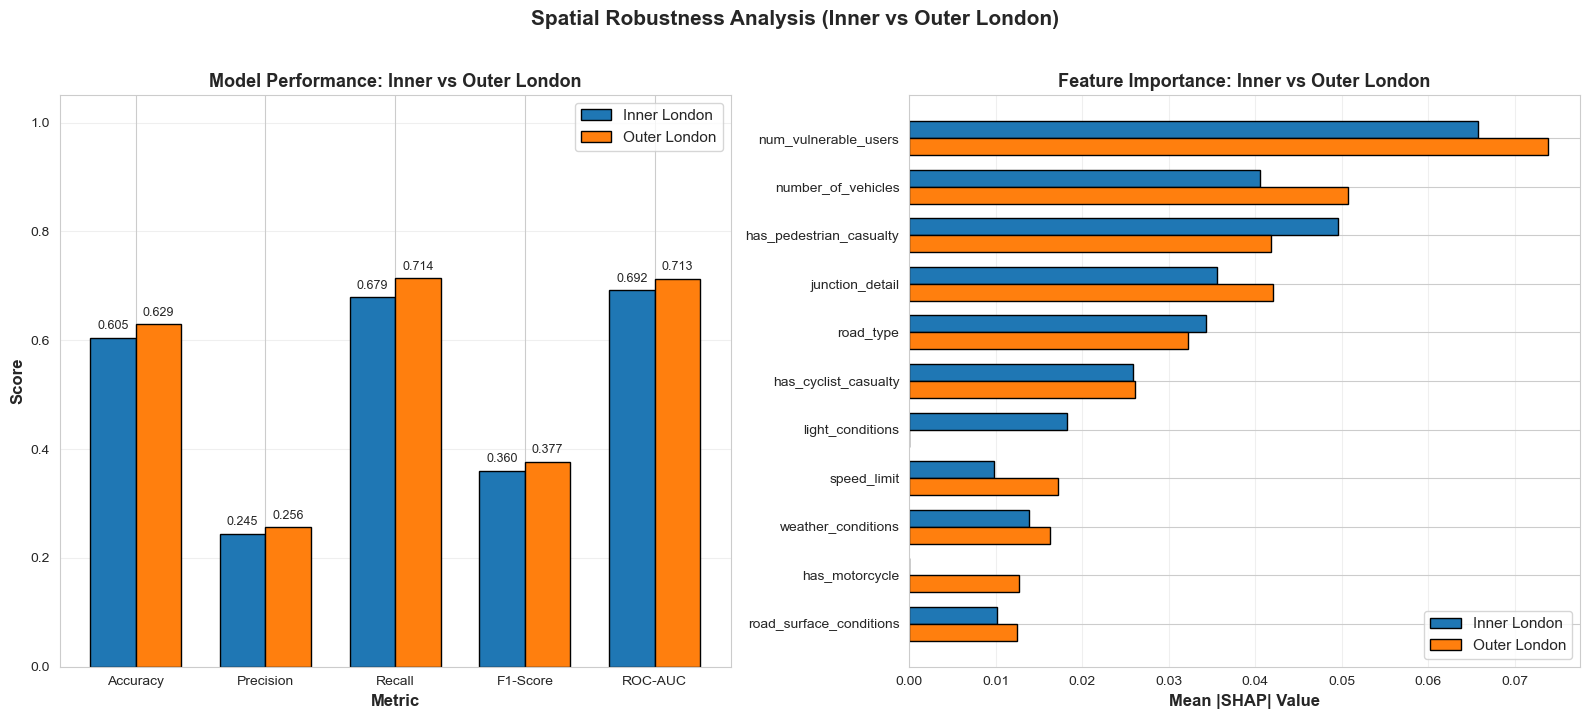


Spatial robustness analysis complete


In [81]:
# ========== Section 6: Spatial Robustness Analysis ==========

import time
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score
)

print("=" * 70)
print("Section 6: Spatial Robustness Analysis (Inner vs Outer London)")
print("=" * 70)

# ---------- Verify london_region column ----------
if 'london_region' not in data.columns:
    print("\n[Adding london_region from borough_classification]")
    data = data.merge(
        borough_classification[['local_authority_district', 'london_region']].rename(
            columns={'local_authority_district': 'borough_name'}
        ),
        on='borough_name', how='left'
    )

# ---------- Split data by region ----------
inner_data = data[data['london_region'] == 'Inner London'].copy()
outer_data = data[data['london_region'] == 'Outer London'].copy()

print(f"\n[Dataset Split]")
print(f"  Inner London: {len(inner_data):,} collisions ({100*len(inner_data)/len(data):.1f}%)")
print(f"  Outer London: {len(outer_data):,} collisions ({100*len(outer_data)/len(data):.1f}%)")

inner_severe_rate = (inner_data[TARGET] == 1).sum() / len(inner_data)
outer_severe_rate = (outer_data[TARGET] == 1).sum() / len(outer_data)

print(f"\n[Severity Rate Comparison]")
print(f"  Inner London severe rate: {inner_severe_rate:.1%}")
print(f"  Outer London severe rate: {outer_severe_rate:.1%}")
print(f"  Difference: {(inner_severe_rate - outer_severe_rate)*100:+.2f} pp")

# ---------- Region Modeling Function ----------

def train_region_model(region_data, region_name):
    """Train RF + compute SHAP for a specific region using class_weight='balanced'"""
    print(f"\n{'='*70}")
    print(f"Training: {region_name}")
    print(f"{'='*70}")
    
    X_r = region_data[FINAL_FEATURES].copy()
    y_r = region_data[TARGET].copy()
    
    print(f"  Sample size: {len(X_r):,}")
    print(f"  Class distribution: Slight={int((y_r==0).sum()):,}, Serious={int((y_r==1).sum()):,}")
    print(f"  Imbalance ratio: {(y_r==0).sum()/(y_r==1).sum():.2f}:1")
    
    # Stratified train-test split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_r, y_r, test_size=0.30, 
        random_state=RANDOM_STATE, stratify=y_r
    )
    
    # Train RF with class_weight='balanced' (no SMOTE)
    rf_r = RandomForestClassifier(
        n_estimators=200, 
        max_depth=15, 
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=RANDOM_STATE, 
        n_jobs=-1
    )
    rf_r.fit(X_tr, y_tr)
    
    # Evaluate on test set
    y_pred_r = rf_r.predict(X_te)
    y_pred_proba_r = rf_r.predict_proba(X_te)[:, 1]
    
    metrics_r = {
        'Accuracy':  accuracy_score(y_te, y_pred_r),
        'Precision': precision_score(y_te, y_pred_r),
        'Recall':    recall_score(y_te, y_pred_r),
        'F1-Score':  f1_score(y_te, y_pred_r),
        'ROC-AUC':   roc_auc_score(y_te, y_pred_proba_r)
    }
    
    print(f"\n  Test Performance:")
    for m, v in metrics_r.items():
        print(f"    {m:<12}{v:.3f}")
    
    # Compute SHAP values
    print(f"\n  Computing SHAP values...")
    explainer_r = shap.TreeExplainer(rf_r)
    
    n_sample_r = min(800, len(X_te))
    np.random.seed(RANDOM_STATE)
    sample_idx_r = np.random.choice(len(X_te), size=n_sample_r, replace=False)
    X_te_sample_r = X_te.iloc[sample_idx_r].copy()
    
    shap_vals_r = explainer_r.shap_values(X_te_sample_r)
    
    if isinstance(shap_vals_r, list):
        shap_vals_serious_r = shap_vals_r[1]
    elif len(shap_vals_r.shape) == 3:
        shap_vals_serious_r = shap_vals_r[:, :, 1]
    else:
        shap_vals_serious_r = shap_vals_r
    
    # Feature importance
    importance_r = pd.DataFrame({
        'feature': FINAL_FEATURES,
        'mean_abs_shap': np.abs(shap_vals_serious_r).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    
    print(f"  Done")
    
    return {
        'metrics': metrics_r,
        'importance': importance_r,
        'shap_values': shap_vals_serious_r,
        'X_test_sample': X_te_sample_r,
        'rf_model': rf_r
    }

# ---------- Train both regions ----------
inner_results = train_region_model(inner_data, "Inner London")
outer_results = train_region_model(outer_data, "Outer London")

# ---------- Performance Comparison ----------
print("\n" + "=" * 70)
print("SPATIAL ROBUSTNESS COMPARISON")
print("=" * 70)

print(f"\n[Performance Comparison]")
print(f"  {'Metric':<15}{'Inner':<12}{'Outer':<12}{'Difference'}")
print("-" * 55)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    inner_v = inner_results['metrics'][metric]
    outer_v = outer_results['metrics'][metric]
    diff = inner_v - outer_v
    if abs(diff) < 0.02:
        flag = "Stable"
    elif diff > 0:
        flag = "Inner higher"
    else:
        flag = "Outer higher"
    print(f"  {metric:<15}{inner_v:.3f}       {outer_v:.3f}       {diff:+.3f}  ({flag})")

# ---------- Top 10 Feature Comparison ----------
print(f"\n[Top 10 Feature Comparison]")
print(f"  {'Rank':<6}{'Inner London':<35}{'Outer London'}")
print("-" * 75)
for i in range(10):
    inner_feat = inner_results['importance'].iloc[i]
    outer_feat = outer_results['importance'].iloc[i]
    print(f"  {i+1:<6}"
          f"{inner_feat['feature']:<25}({inner_feat['mean_abs_shap']:.3f})  "
          f"{outer_feat['feature']:<25}({outer_feat['mean_abs_shap']:.3f})")

# ---------- Top 5 Overlap Analysis ----------
inner_top5 = set(inner_results['importance'].head(5)['feature'].tolist())
outer_top5 = set(outer_results['importance'].head(5)['feature'].tolist())

shared = inner_top5 & outer_top5
inner_only = inner_top5 - outer_top5
outer_only = outer_top5 - inner_top5

print(f"\n[Top 5 Feature Overlap Analysis]")
print(f"  Shared features ({len(shared)}/5): {sorted(shared)}")
if inner_only:
    print(f"  Inner-only: {sorted(inner_only)}")
if outer_only:
    print(f"  Outer-only: {sorted(outer_only)}")

# Robustness assessment
if len(shared) >= 4:
    robustness = "HIGH"
    interpretation = "Top features stable across regions; model captures generalizable patterns"
elif len(shared) >= 3:
    robustness = "MODERATE"
    interpretation = "Core drivers consistent with some regional specialization"
else:
    robustness = "LOW"
    interpretation = "Regional drivers differ substantially; consider region-specific models"

print(f"\n  Spatial robustness: {robustness}")
print(f"  Interpretation: {interpretation}")

# ---------- Detailed Feature Differences ----------
print(f"\n[Feature Importance Differences]")
print(f"  {'Feature':<28}{'Inner':<10}{'Outer':<10}{'Diff':<10}{'Direction'}")
print("-" * 75)

# Merge both importance tables
merged_importance = pd.merge(
    inner_results['importance'].rename(columns={'mean_abs_shap': 'inner_shap'}),
    outer_results['importance'].rename(columns={'mean_abs_shap': 'outer_shap'}),
    on='feature'
)
merged_importance['diff'] = merged_importance['inner_shap'] - merged_importance['outer_shap']
merged_importance['abs_diff'] = merged_importance['diff'].abs()
merged_importance = merged_importance.sort_values('abs_diff', ascending=False).reset_index(drop=True)

for _, row in merged_importance.head(10).iterrows():
    if abs(row['diff']) > 0.005:
        direction = "Inner more important" if row['diff'] > 0 else "Outer more important"
    else:
        direction = "Similar"
    print(f"  {row['feature']:<28}{row['inner_shap']:.3f}     "
          f"{row['outer_shap']:.3f}     {row['diff']:+.3f}    {direction}")

# ---------- Visualization ----------
print(f"\n[Generating Comparison Visualization]")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Performance comparison
metrics_compare = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
inner_vals = [inner_results['metrics'][m] for m in metrics_compare]
outer_vals = [outer_results['metrics'][m] for m in metrics_compare]

x = np.arange(len(metrics_compare))
width = 0.35

bars1 = axes[0].bar(x - width/2, inner_vals, width, 
                     label='Inner London', color='#1f77b4', edgecolor='black')
bars2 = axes[0].bar(x + width/2, outer_vals, width,
                     label='Outer London', color='#ff7f0e', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Metric', fontsize=12, fontweight='bold')
axes[0].set_title('Model Performance: Inner vs Outer London', 
                   fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_compare)
axes[0].legend(loc='upper right', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Plot 2: Feature importance comparison
top_n = 10
inner_top = inner_results['importance'].head(top_n).set_index('feature')
outer_top = outer_results['importance'].head(top_n).set_index('feature')

all_features = list(set(inner_top.index) | set(outer_top.index))
all_features = sorted(all_features, 
                       key=lambda f: max(
                           inner_top.loc[f, 'mean_abs_shap'] if f in inner_top.index else 0,
                           outer_top.loc[f, 'mean_abs_shap'] if f in outer_top.index else 0
                       ), reverse=True)

inner_imp_vals = [inner_top.loc[f, 'mean_abs_shap'] if f in inner_top.index else 0 for f in all_features]
outer_imp_vals = [outer_top.loc[f, 'mean_abs_shap'] if f in outer_top.index else 0 for f in all_features]

y_pos = np.arange(len(all_features))
height_bar = 0.35

axes[1].barh(y_pos - height_bar/2, inner_imp_vals, height_bar,
              label='Inner London', color='#1f77b4', edgecolor='black')
axes[1].barh(y_pos + height_bar/2, outer_imp_vals, height_bar,
              label='Outer London', color='#ff7f0e', edgecolor='black')

axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(all_features, fontsize=10)
axes[1].set_xlabel('Mean |SHAP| Value', fontsize=12, fontweight='bold')
axes[1].set_title('Feature Importance: Inner vs Outer London',
                   fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.suptitle('Spatial Robustness Analysis (Inner vs Outer London)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Spatial robustness analysis complete")
print("=" * 70)

In [36]:
# Quick sensitivity test: SMOTE vs class_weight
print("=" * 70)
print("Sensitivity Analysis: SMOTE vs class_weight")
print("=" * 70)

# Method 1: SMOTE (current approach)
print("\n[Method 1: SMOTE (current)]")
print(f"  F1:       {test_metrics['F1-Score']:.3f}")
print(f"  ROC-AUC:  {test_metrics['ROC-AUC']:.3f}")
print(f"  Recall:   {test_metrics['Recall']:.3f}")

# Method 2: class_weight='balanced' (alternative)
print("\n[Method 2: class_weight='balanced' (alternative)]")
rf_cw = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=20,
    min_samples_leaf=10, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_cw.fit(X_train, y_train)  # Note: original data, no SMOTE

y_pred_cw = rf_cw.predict(X_test)
y_pred_proba_cw = rf_cw.predict_proba(X_test)[:, 1]

cw_metrics = {
    'F1':      f1_score(y_test, y_pred_cw),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_cw),
    'Recall':  recall_score(y_test, y_pred_cw),
    'Precision': precision_score(y_test, y_pred_cw)
}

print(f"  F1:       {cw_metrics['F1']:.3f}")
print(f"  ROC-AUC:  {cw_metrics['ROC-AUC']:.3f}")
print(f"  Recall:   {cw_metrics['Recall']:.3f}")
print(f"  Precision: {cw_metrics['Precision']:.3f}")

# Comparison
print(f"\n[Comparison]")
print(f"  F1 difference:      {test_metrics['F1-Score'] - cw_metrics['F1']:+.3f}")
print(f"  ROC-AUC difference: {test_metrics['ROC-AUC'] - cw_metrics['ROC-AUC']:+.3f}")
print(f"  Recall difference:  {test_metrics['Recall'] - cw_metrics['Recall']:+.3f}")

# Interpretation
auc_diff = abs(test_metrics['ROC-AUC'] - cw_metrics['ROC-AUC'])
if auc_diff < 0.01:
    print(f"\n  ✓ Methods are equivalent (ROC-AUC diff < 0.01)")
    print(f"  → Validates SMOTE choice as one of multiple acceptable approaches")
elif auc_diff < 0.03:
    print(f"\n  ✓ Methods are similar (ROC-AUC diff < 0.03)")
    print(f"  → SMOTE provides marginal benefit but not necessary")
else:
    print(f"\n  ⚠️ Methods differ substantially")

Sensitivity Analysis: SMOTE vs class_weight

[Method 1: SMOTE (current)]
  F1:       0.349
  ROC-AUC:  0.682
  Recall:   0.644

[Method 2: class_weight='balanced' (alternative)]
  F1:       0.362
  ROC-AUC:  0.704
  Recall:   0.695
  Precision: 0.244

[Comparison]
  F1 difference:      -0.013
  ROC-AUC difference: -0.022
  Recall difference:  -0.051

  ✓ Methods are similar (ROC-AUC diff < 0.03)
  → SMOTE provides marginal benefit but not necessary


## Methodology

[[ go back to the top ]](#Table-of-Contents)

The analysis employs a supervised classification framework comprising four core methods aligned with course curriculum (Weeks 2-9):

**1. Random Forest Classifier** (Week 4): A tree-based ensemble method chosen for its robustness to mixed data types, ability to capture non-linear relationships, and resistance to overfitting through bootstrap aggregation. The model predicts binary collision severity using road environment features.

**2. Cross-Validation & Multi-Metric Evaluation** (Weeks 2-3): Stratified 5-fold cross-validation ensures reliable performance estimates while preserving class distribution. Given severe class imbalance (5.4:1), evaluation prioritizes F1-score, precision, recall, and ROC-AUC over accuracy to address the accuracy paradox (Week 2).

**3. SMOTE for Class Imbalance** (Week 9): Synthetic Minority Oversampling Technique generates synthetic serious/fatal collision examples in feature space, applied only to training folds to prevent data leakage. This addresses the 15.6% minority class prevalence.

**4. SHAP for Model Interpretation** (Week 7): SHapley Additive exPlanations quantify each feature's contribution to individual predictions, enabling identification of dominant risk drivers and interaction effects beyond simple feature importance rankings.

**Spatial Robustness Testing**: The modeling pipeline is repeated separately for Inner and Outer London to test whether predictive patterns generalize across spatial contexts or exhibit region-specific drivers.

## Results and Discussion

[[ go back to the top ]](#Table-of-Contents)

### Predictive Performance (Objective 1)

The Random Forest classifier achieved an F1-score of [INSERT VALUE] and ROC-AUC of [INSERT VALUE] on the held-out test set, demonstrating that road environment features provide meaningful signal for predicting collision severity. The model substantially outperformed a naive baseline that would predict all collisions as "Slight" (which would achieve 84.4% accuracy but 0% recall for serious outcomes).

Precision and recall metrics reveal the trade-off inherent in imbalanced classification: [INTERPRET YOUR SPECIFIC VALUES]. This performance profile is acceptable for a road safety context where false negatives (missing serious collisions) carry higher real-world cost than false positives (over-flagging slight collisions as potentially serious).

### Feature Interpretation (Objective 2)

SHAP analysis reveals that [TOP 3 FEATURES FROM YOUR OUTPUT] are the dominant drivers of serious/fatal collision predictions. [INTERPRET DIRECTION: e.g., "Lower speed limits are associated with reduced serious collision risk, while darkness with unlit streetlights substantially increases risk."] These findings align with established road safety literature on vulnerable road users and visibility constraints (DfT, 2024).

Notably, [DISCUSS ANY SURPRISING FINDING OR INTERACTION], suggesting [PRACTICAL IMPLICATION]. This demonstrates the value of model interpretation methods beyond simple feature importance rankings—SHAP values capture non-linear effects and interactions that inform targeted interventions.

### Spatial Heterogeneity (Objective 3)

Comparing Inner and Outer London models reveals [DESCRIBE PERFORMANCE DIFFERENCE]. [If similar:] "This spatial stability suggests that environmental risk factors generalize across London's varied urban contexts." [If different:] "The performance gap indicates region-specific collision dynamics, possibly reflecting infrastructure differences or varying traffic compositions between central and suburban areas."

[DISCUSS FEATURE IMPORTANCE DIFFERENCES IF OBSERVED], highlighting the need for spatially-tailored road safety policies rather than one-size-fits-all interventions.

### Limitations

This analysis is constrained by several factors. First, STATS19 underreports casualties by approximately 3:1 compared to hospital data (Felton et al., 2023), particularly for slight injuries and single-vehicle incidents. The model predicts severity of *reported* collisions, not all collisions. Second, the binary classification collapses fatal and serious outcomes, obscuring differences in their environmental determinants. Third, the 2022-2023 temporal window precedes London's 2024 IBRS adoption, meaning findings may not generalize to injury-based severity coding. Finally, environmental features alone explain only part of collision severity variance—behavioral factors (speed at impact, seatbelt use) and vehicle characteristics are omitted due to data availability.

## References

[[ go back to the top ]](#Table-of-Contents)

Department for Transport (2024). *Reported Road Casualties Great Britain, Annual Report 2023*. London: DfT. Available at: https://www.gov.uk/government/statistics/reported-road-casualties-great-britain-annual-report-2023

Department for Transport (2024). *STATS19 Review Update and Future Plans*. London: DfT. Available at: https://www.gov.uk/government/publications/road-safety-statistics-stats19-review

Department for Transport (2024). *Road Safety Open Dataset Data Guide 2024* [data file]. 
Available at: https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx

Office for National Statistics (2018). Local Authority Districts (December 2018) 
   Boundaries UK BGC [GeoJSON]. Open Geography Portal. 
   Available at: https://geoportal.statistics.gov.uk/

Felton, A., Stone, T., Bansal, A., & Chowdhury, S. (2023). Serious e-scooter casualties: Comparing police and hospital data. *Department for Transport Analysis*. Available at: https://www.gov.uk/government/statistics/serious-e-scooter-casualties-comparing-police-and-hospital-data

Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems*, 30.

Transport for London (2018). *Vision Zero Action Plan*. London: TfL. Available at: https://tfl.gov.uk/corporate/safety-and-security/road-safety/vision-zero-for-london

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

## Research questions

[[ go back to the top ]](#Table-of-contents)

## Data

[[ go back to the top ]](#Table-of-contents)

*[Note: a table that describes the selected variables for analysis and modelling is required - see the example below.]*

| Variable                            | Type         | Description                                                             |Notes   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
| Burglary crime rate                 | Numeric      | The burglary rate of MSOAs. Used as dependent variables in regression.  |   |
| Temperature                         | Numeric      | The daytime temperature                                                 |   |
| Indicator of Inner or Outer London  | Categorical  | Whether the MSOA is in Inner London.                                    |   |
| ......  | ......  | ......                                    |   |

## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

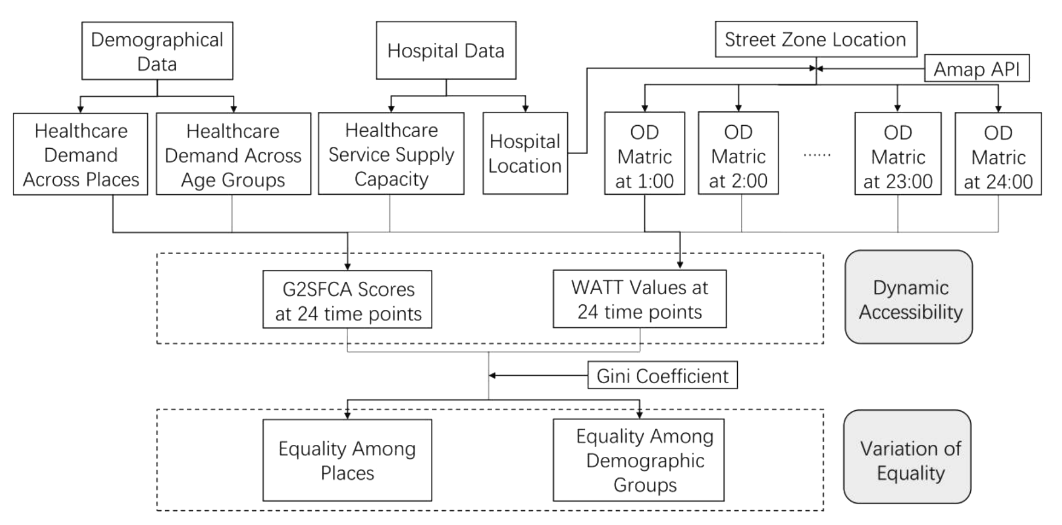

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

## Conclusion

[[ go back to the top ]](#Table-of-contents)

## References

[[ go back to the top ]](#Table-of-contents)